In [37]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/radistakriska/kicawmania/bali_dataset_mapped.csv
/kaggle/input/datasets/radistakriska/kicawmania/etsy.csv


In [38]:

# ──────────────────────────────────────────────────────────────
# 0. INSTALL (jalankan sekali di terminal/Kaggle sebelum script ini)
# ──────────────────────────────────────────────────────────────
!pip install xgboost==2.1.1 sentence-transformers==3.0.1 shap nltk

In [39]:
# ──────────────────────────────────────────────────────────────
# 1. IMPORT SEMUA LIBRARY
# ──────────────────────────────────────────────────────────────
import re
import time
import warnings
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import nltk
nltk.download("punkt",                      quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("wordnet",                    quiet=True)
nltk.download("omw-1.4",                    quiet=True)

from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sentence_transformers import SentenceTransformer
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

print("✅ Semua library berhasil diimport!")
print(f"   XGBoost versi   : {__import__('xgboost').__version__}")
print(f"   SentTrans versi : {__import__('sentence_transformers').__version__}\n")



✅ Semua library berhasil diimport!
   XGBoost versi   : 2.1.1
   SentTrans versi : 3.0.1



In [40]:
# ──────────────────────────────────────────────────────────────
# 2. KONFIGURASI GLOBAL
# ──────────────────────────────────────────────────────────────
BALI_CSV_PATH   = "/kaggle/input/datasets/radistakriska/kicawmania/bali_dataset_mapped.csv"
GLOBAL_CSV_PATH = "/kaggle/input/datasets/radistakriska/kicawmania/etsy.csv"
OUTPUT_ARTIFACT = "wantilan_kriya_v2.joblib"
OUTPUT_CSV      = "bali_dataset_engineered_v2.csv"

PRICE_CAP_USD   = 150
EXCHANGE_RATE   = 18_300
BERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"  # Full HF path untuk konsistensi
RANDOM_STATE    = 42

# Konstanta yang HARUS sama antara training dan inference
MATERIALS     = ["wood", "silver", "gold", "rattan", "leather",
                 "cotton", "silk", "stone", "digital"]
PREMIUM_WORDS = ["premium", "luxury", "authentic", "exclusive",
                 "masterpiece", "custom", "personalized"]
BALI_KEYWORDS = ["bali", "balinese", "indonesia", "ubud", "lombok",
                 "jogja", "yogyakarta", "jawa", "batik", "tenun"]

CORE_COLS = ["name", "description", "category", "brand",
             "product_details", "average_rating", "reviews_count", "price"]

NUM_COLS = [
    "average_rating", "reviews_log", "trust_score",
    "text_word_count", "category_te", "is_bali", "category_depth",
    "char_count", "avg_word_length", "premium_keyword_count",
    "engagement_rate", "is_bestseller", "category_tier"
] + [f"has_{mat}" for mat in MATERIALS]


In [41]:
# ══════════════════════════════════════════════════════════════
# PHASE 3 │ TEXT PREPROCESSING  ← DIDEFINISIKAN DULU SEBELUM DATA LOADING
# (Satu definisi, dipakai KONSISTEN di training DAN inference)
# ══════════════════════════════════════════════════════════════

NLTK_STOPWORDS = set("""
i me my myself we our ours ourselves you your yours yourself yourselves
he him his himself she her hers herself it its itself they them their theirs themselves
what which who whom this that these those am is are was were be been being
have has had having do does did doing a an the and but if or because as until while
of at by for with about against between into through during before after above below
to from up down in out on off over under again further then once here there when
where why how all any both each few more most other some such no nor not only own
same so than too very s t can will just don should now
""".split())

CUSTOM_STOPWORDS = {
    "quot", "amp", "nbsp", "http", "https", "www", "com",
    "etsy", "shop", "item", "listing",
    "please", "note", "use", "using",
    "available", "high", "quality", "new",
    "great", "best", "perfect", "beautiful",
    "cm", "inch", "size", "small", "large", "medium"
}

ALL_STOPWORDS = ENGLISH_STOP_WORDS.union(NLTK_STOPWORDS).union(CUSTOM_STOPWORDS)
lemmatizer    = WordNetLemmatizer()


def keep_pos(tag: str) -> bool:
    """Simpan Noun, Adjective, Verb saja."""
    return tag.startswith("NN") or tag.startswith("JJ") or tag.startswith("VB")


def clean_text(text: str) -> str:
    """
    ⚠️ FUNGSI INI ADALAH SATU-SATUNYA FUNGSI TEXT CLEANING.
    Dipakai IDENTIK di training (Kaggle) dan inference (lokal/Docker).
    
    Pipeline: lowercase → strip symbol → tokenize → 
              stopword filter → POS filter → lemmatize → deduplicate
    """
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    
    tokens  = word_tokenize(text)
    tokens  = [w for w in tokens if w not in ALL_STOPWORDS and len(w) > 2]
    tagged  = pos_tag(tokens)
    filtered = [w for w, t in tagged if keep_pos(t)]
    lemmas  = [lemmatizer.lemmatize(w) for w in filtered]
    lemmas  = list(dict.fromkeys(lemmas))          # deduplicate, jaga urutan
    
    return " ".join(lemmas)



In [42]:

# ══════════════════════════════════════════════════════════════
# PHASE 1 │ LOAD & MERGE DATASET
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("PHASE 1 │ LOAD & MERGE DATASET")
print("=" * 60)

df_bali   = pd.read_csv(BALI_CSV_PATH)[CORE_COLS].copy()
df_global = pd.read_csv(GLOBAL_CSV_PATH)[CORE_COLS].copy()

df_bali["is_bali"]   = 1
df_global["is_bali"] = 0

df_all = pd.concat([df_bali, df_global], ignore_index=True)
print(f"  Bali    : {len(df_bali):,} baris")
print(f"  Global  : {len(df_global):,} baris")
print(f"  Gabungan: {len(df_all):,} baris | {df_all.shape[1]} kolom\n")



PHASE 1 │ LOAD & MERGE DATASET
  Bali    : 3,999 baris
  Global  : 10,406 baris
  Gabungan: 14,405 baris | 9 kolom



In [43]:
print("=" * 60)
print("EDA 1 │ BASIC DATASET INSPECTION")
print("=" * 60)

print("\n📦 SHAPE DATASET")
print(df_all.shape)

print("\n📊 DATA TYPES")
print(df_all.dtypes)

print("\n🕳️ MISSING VALUES (%)")

missing = (
    df_all.isnull().sum() /
    len(df_all) * 100
).sort_values(ascending=False)

print(
    missing[missing > 0]
    .round(2)
)

print("\n📂 UNIQUE CATEGORIES")
print(df_all["category"].nunique())

print("\n🏷️ UNIQUE BRANDS")
print(df_all["brand"].nunique())

print("\n🔁 DUPLICATES")
print(df_all.duplicated().sum())

EDA 1 │ BASIC DATASET INSPECTION

📦 SHAPE DATASET
(14405, 9)

📊 DATA TYPES
name                object
description         object
category            object
brand               object
product_details     object
average_rating     float64
reviews_count        int64
price              float64
is_bali              int64
dtype: object

🕳️ MISSING VALUES (%)
product_details    0.33
dtype: float64

📂 UNIQUE CATEGORIES
305

🏷️ UNIQUE BRANDS
3720

🔁 DUPLICATES
38


Cleaning
remove duplicates
fill missing text

EDA 2 │ PRICE DISTRIBUTION
count    14405.00
mean       105.26
std        360.81
min          0.20
25%         21.00
50%         46.88
75%        125.00
max      39999.00
Name: price, dtype: float64


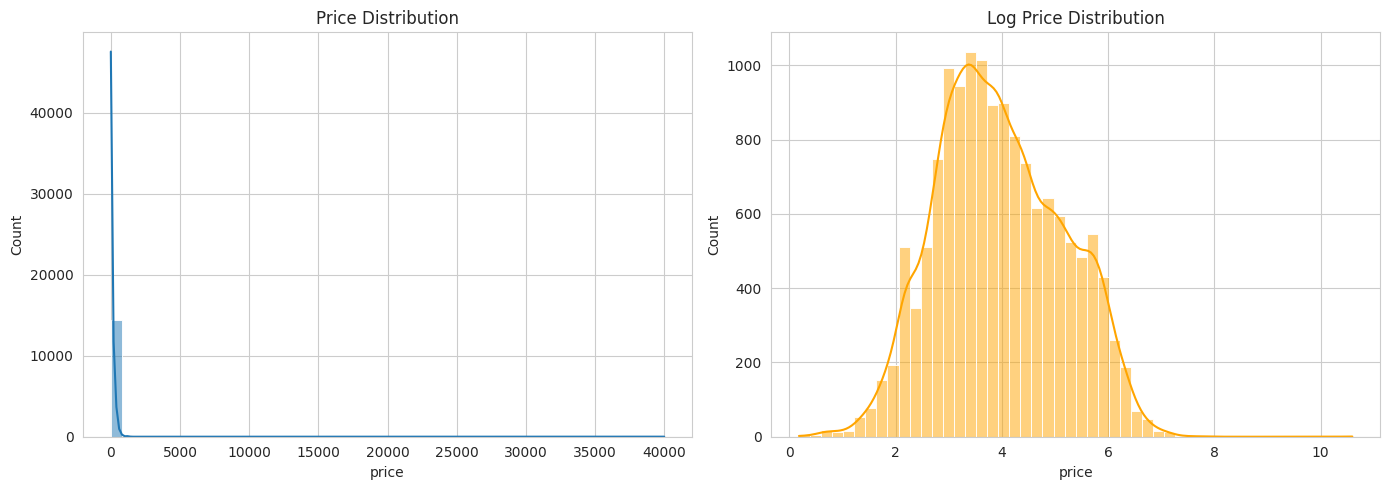

In [44]:
print("=" * 60)
print("EDA 2 │ PRICE DISTRIBUTION")
print("=" * 60)

print(df_all["price"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df_all["price"],
    bins=50,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Price Distribution")

sns.histplot(
    np.log1p(df_all["price"]),
    bins=50,
    kde=True,
    color="orange",
    ax=axes[1]
)

axes[1].set_title("Log Price Distribution")

plt.tight_layout()
plt.show()

Pertimbangkan:
clipping outlier
winsorization
quantile filtering

EDA 3 │ BALI vs GLOBAL
           count    mean     std   min    25%     50%    75%      max
is_bali                                                              
0        10406.0   61.55  399.93  0.20  18.00   33.00   66.5  39999.0
1         3999.0  218.99  186.68  7.74  76.03  175.89  315.0   1950.0


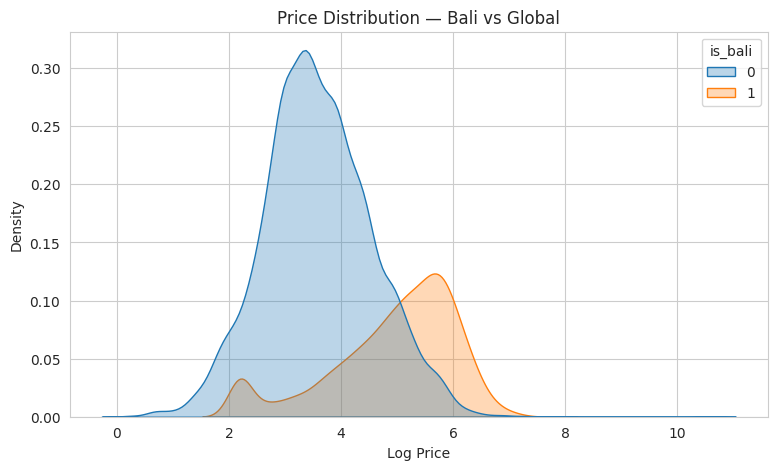

In [45]:
print("=" * 60)
print("EDA 3 │ BALI vs GLOBAL")
print("=" * 60)

# pastikan kolom ada
df_all["price_log"] = np.log1p(df_all["price"])

group_stats = (
    df_all
    .groupby("is_bali")["price"]
    .describe()
    .round(2)
)

print(group_stats)

plt.figure(figsize=(9,5))

sns.kdeplot(
    data=df_all,
    x="price_log",
    hue="is_bali",
    fill=True,
    alpha=0.3
)

plt.title("Price Distribution — Bali vs Global")
plt.xlabel("Log Price")
plt.show()

embedding

In [46]:
print("=" * 60)
print("TEXT CLEANING │ CREATE text_clean")
print("=" * 60)

# Gabungkan semua text
df_all["text_raw"] = (
    df_all["name"].fillna("") + " " +
    df_all["description"].fillna("") + " " +
    df_all["category"].fillna("") + " " +
    df_all["product_details"].fillna("")
)

print("⏳ Cleaning text...")

df_all["text_clean"] = (
    df_all["text_raw"]
    .apply(clean_text)
)

print("✅ text_clean berhasil dibuat!")

print("\n📄 SAMPLE CLEAN TEXT:")
print(df_all["text_clean"].head())

TEXT CLEANING │ CREATE text_clean
⏳ Cleaning text...
✅ text_clean berhasil dibuat!

📄 SAMPLE CLEAN TEXT:
0    authentic organic bali byzantine chain necklac...
1    rare ubud art buddha relief panel wood carving...
2    handcrafted balinese craft dragon bone bracele...
3    unique balinese heritage byzantine chain neckl...
4    authentic balinese heritage turquoise silver b...
Name: text_clean, dtype: object


Simpan feature:
text_length
Tambahkan :
char_count
avg_word_length

In [47]:
print("=" * 60)
print("EDA 5 │ TOP WORD ANALYSIS")
print("=" * 60)

def get_top_words(text_series, n=20):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)

top_words = get_top_words(
    df_all["text_clean"],
    20
)

for word, count in top_words:
    print(f"{word:<20} {count}")

EDA 5 │ TOP WORD ANALYSIS
handmade             10005
material             8405
accessory            6833
wedding              6679
order                5441
color                4929
gift                 4702
day                  4346
bridal               4101
piece                4087
home                 4006
time                 3976
shipping             3855
hand                 3750
custom               3715
bali                 3695
balinese             3635
make                 3501
indonesia            3217
white                3205


EDA 6 │ WORDCLOUD


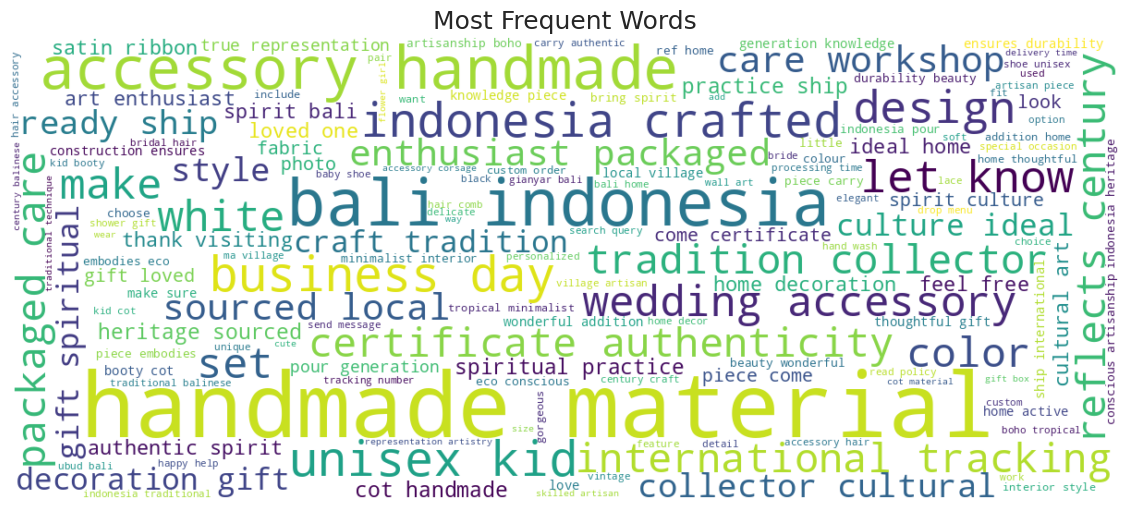

In [48]:
from wordcloud import WordCloud

print("=" * 60)
print("EDA 6 │ WORDCLOUD")
print("=" * 60)

text = " ".join(df_all["text_clean"])

wc = WordCloud(
    width=1200,
    height=500,
    background_color="white",
    max_words=150,
    colormap="viridis"
).generate(text)

plt.figure(figsize=(15,6))

plt.imshow(wc, interpolation="bilinear")

plt.axis("off")

plt.title(
    "Most Frequent Words",
    fontsize=18
)

plt.show()

Semantic theme lebih penting daripada brand.
Embedding NLP akan efektif karena pola kata konsisten.
Bali products punya strong branding identity.

In [49]:
# ══════════════════════════════════════════════════════════════
# EDA 7 │ TOP WORDS — CHEAP vs EXPENSIVE
# ══════════════════════════════════════════════════════════════

from collections import Counter

print("=" * 60)
print("EDA 7 │ TOP WORDS — CHEAP vs EXPENSIVE")
print("=" * 60)

# Pastikan kolom ada
if "price_log" not in df_all.columns:
    df_all["price_log"] = np.log1p(df_all["price"])

if "text_clean" not in df_all.columns:
    raise ValueError("❌ text_clean belum dibuat!")

# Bagi murah vs mahal
median_price = df_all["price"].median()

df_all["price_group"] = np.where(
    df_all["price"] >= median_price,
    "expensive",
    "cheap"
)

cheap_text = " ".join(
    df_all[df_all["price_group"] == "cheap"]["text_clean"]
)

exp_text = " ".join(
    df_all[df_all["price_group"] == "expensive"]["text_clean"]
)

cheap_words = Counter(cheap_text.split()).most_common(20)
exp_words   = Counter(exp_text.split()).most_common(20)

print(f"\n💸 CHEAP PRODUCTS (<= ${median_price:.2f})")
for word, count in cheap_words:
    print(f"{word:<20} {count}")

print(f"\n💎 EXPENSIVE PRODUCTS (> ${median_price:.2f})")
for word, count in exp_words:
    print(f"{word:<20} {count}")

EDA 7 │ TOP WORDS — CHEAP vs EXPENSIVE

💸 CHEAP PRODUCTS (<= $46.88)
handmade             6126
material             5150
accessory            3945
wedding              3720
order                3245
color                3134
gift                 2615
day                  2557
time                 2235
shipping             2221
make                 2149
baby                 2144
custom               2089
bridal               1949
shoe                 1933
white                1921
contact              1889
hand                 1836
flower               1691
free                 1683

💎 EXPENSIVE PRODUCTS (> $46.88)
handmade             3879
material             3255
bali                 3074
balinese             3034
wedding              2959
accessory            2888
indonesia            2662
piece                2650
home                 2593
order                2196
bridal               2152
gift                 2087
hand                 1914
sourced              1893
art           

In [50]:
# ══════════════════════════════════════════════════════════════
# EDA 8 │ PREMIUM & MATERIAL ANALYSIS
# ══════════════════════════════════════════════════════════════

print("=" * 60)
print("EDA 8 │ PREMIUM & MATERIAL ANALYSIS")
print("=" * 60)

print("\n⭐ PREMIUM WORDS")

for word in PREMIUM_WORDS:

    count = (
        df_all["text_clean"]
        .str.contains(fr"\b{word}\b", regex=True, na=False)
        .sum()
    )

    pct = count / len(df_all) * 100

    print(f"{word:<15} {count:>5} ({pct:.2f}%)")

print("\n🪵 MATERIAL WORDS")

for mat in MATERIALS:

    count = (
        df_all["text_clean"]
        .str.contains(fr"\b{mat}\b", regex=True, na=False)
        .sum()
    )

    pct = count / len(df_all) * 100

    print(f"{mat:<15} {count:>5} ({pct:.2f}%)")

EDA 8 │ PREMIUM & MATERIAL ANALYSIS

⭐ PREMIUM WORDS
premium           756 (5.25%)
luxury            410 (2.85%)
authentic        1079 (7.49%)
exclusive         219 (1.52%)
masterpiece       822 (5.71%)
custom           3715 (25.79%)
personalized      856 (5.94%)

🪵 MATERIAL WORDS
wood             1622 (11.26%)
silver           2391 (16.60%)
gold             1834 (12.73%)
rattan            682 (4.73%)
leather           980 (6.80%)
cotton           1398 (9.70%)
silk             1178 (8.18%)
stone             471 (3.27%)
digital           565 (3.92%)


Material adalah strong pricing signal.
Silver/gold products kemungkinan premium.
Customization meningkatkan willingness-to-pay.

In [51]:
# ══════════════════════════════════════════════════════════════
# EDA 9 │ TF-IDF TOP KEYWORDS
# ══════════════════════════════════════════════════════════════

from sklearn.feature_extraction.text import TfidfVectorizer

print("=" * 60)
print("EDA 9 │ TF-IDF TOP KEYWORDS")
print("=" * 60)

sample_size = min(5000, len(df_all))

df_sample = df_all.sample(
    sample_size,
    random_state=42
)

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X_tfidf = vectorizer.fit_transform(
    df_sample["text_clean"]
)

feature_names = vectorizer.get_feature_names_out()

scores = np.asarray(
    X_tfidf.mean(axis=0)
).ravel()

top_idx = scores.argsort()[-20:][::-1]

print("\n🔥 TOP TF-IDF KEYWORDS\n")

for idx in top_idx:

    word  = feature_names[idx]
    score = scores[idx]

    print(f"{word:<20} {score:.5f}")

EDA 9 │ TF-IDF TOP KEYWORDS

🔥 TOP TF-IDF KEYWORDS

handmade             0.03826
material             0.03508
accessory            0.03359
wedding              0.03277
bali                 0.03080
balinese             0.03064
indonesia            0.02890
gift                 0.02856
home                 0.02816
piece                0.02795
order                0.02661
color                0.02610
bridal               0.02537
hand                 0.02339
day                  0.02303
sourced              0.02225
art                  0.02225
hair                 0.02207
custom               0.02194
shipping             0.02183


EDA 10 │ CORRELATION HEATMAP


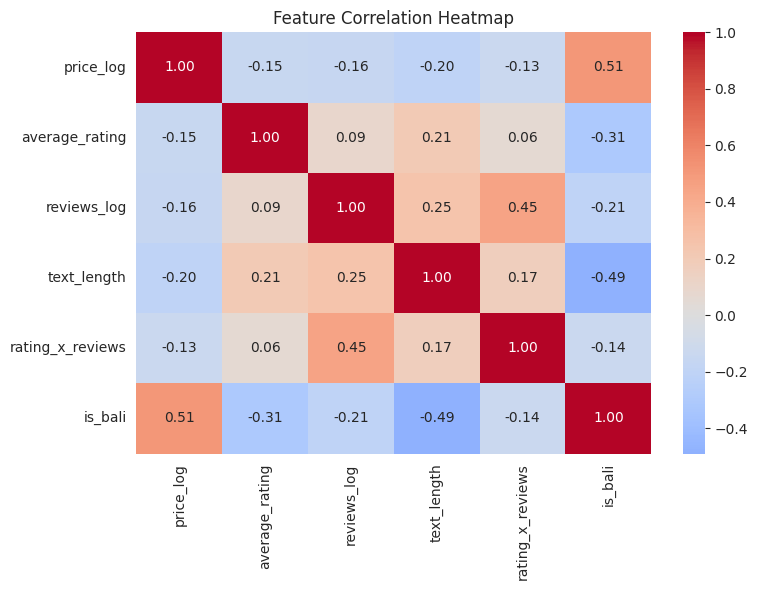

In [52]:
# ══════════════════════════════════════════════════════════════
# EDA 10 │ CORRELATION HEATMAP
# ══════════════════════════════════════════════════════════════

print("=" * 60)
print("EDA 10 │ CORRELATION HEATMAP")
print("=" * 60)

# Feature tambahan
df_all["reviews_log"] = np.log1p(
    df_all["reviews_count"]
)

df_all["text_length"] = (
    df_all["text_clean"]
    .apply(lambda x: len(x.split()))
)

df_all["rating_x_reviews"] = (
    df_all["average_rating"] *
    df_all["reviews_count"]
)

corr_cols = [
    "price_log",
    "average_rating",
    "reviews_log",
    "text_length",
    "rating_x_reviews",
    "is_bali"
]

corr_matrix = (
    df_all[corr_cols]
    .corr()
)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

EDA 11 │ CATEGORY ANALYSIS
                                                    count    mean  median  \
category                                                                    
Silver Jewelry                                        407  322.28  300.58   
Paintings on Canvas                                   412  314.66  260.68   
Home Decor                                            417  186.83  149.54   
Batik & Textile                                       404  148.54  102.72   
Incense & Aromatherapy                                407  123.99   43.50   
Weddings < Accessories < Veils                        693   98.78   69.99   
Weddings < Accessories < Bouquets & Corsages < ...    902   95.76   62.36   
Weddings < Accessories < Hair Accessories             464   51.14   40.00   
Weddings < Accessories                                583   34.25   20.00   
Shoes < Unisex Kids' Shoes < Booties & Cot Shoes     1052   25.82   22.62   

                                                

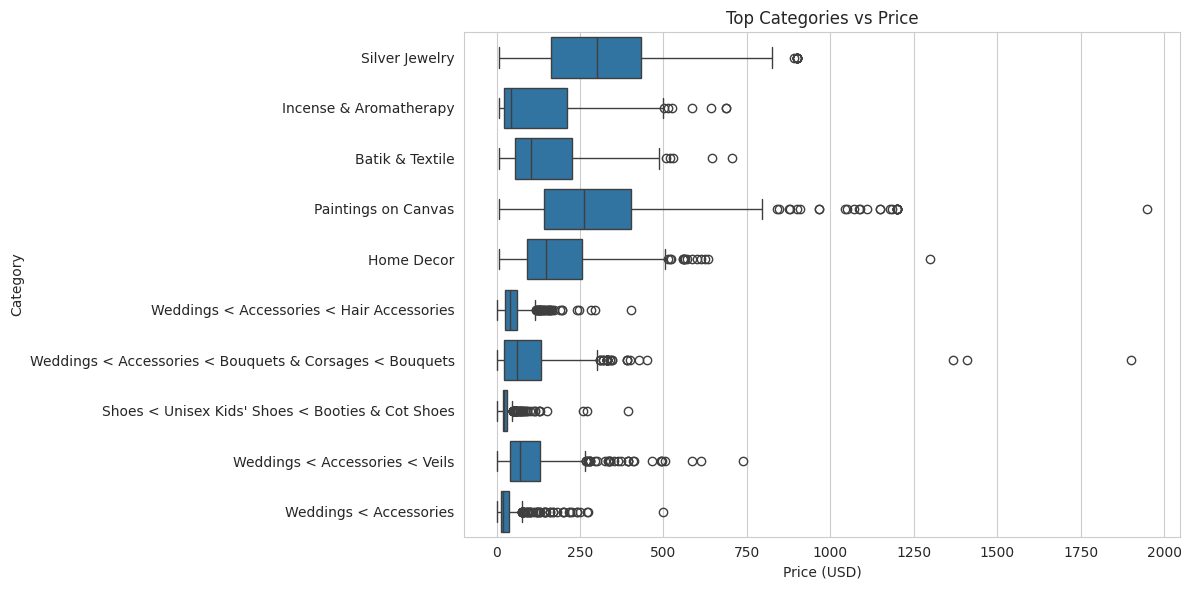

In [53]:
# ══════════════════════════════════════════════════════════════
# EDA 11 │ CATEGORY ANALYSIS
# ══════════════════════════════════════════════════════════════

print("=" * 60)
print("EDA 11 │ CATEGORY ANALYSIS")
print("=" * 60)

top_categories = (
    df_all["category"]
    .value_counts()
    .head(10)
    .index
)

cat_stats = (
    df_all[
        df_all["category"].isin(top_categories)
    ]
    .groupby("category")["price"]
    .agg(["count", "mean", "median", "max"])
    .sort_values("mean", ascending=False)
    .round(2)
)

print(cat_stats)

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_all[
        df_all["category"].isin(top_categories)
    ],
    x="price",
    y="category"
)

plt.title("Top Categories vs Price")

plt.xlabel("Price (USD)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [54]:
"""
=============================================================
WANTILAN KRIYA v2.1
IMPROVED CLEANING + NLP PIPELINE
=============================================================

TUJUAN:
- Membersihkan dataset lebih robust
- Mengurangi noise text Etsy
- Menstabilkan distribusi harga
- Membuat inference lebih konsisten
- Meningkatkan kualitas feature engineering

REASONING BERDASARKAN EDA:
-------------------------------------------------------------
EDA 1:
- ditemukan duplicate
- missing values pada product_details

EDA 2:
- distribusi harga sangat skewed
- mean jauh lebih besar dari median
- ada outlier ekstrem sampai $39,999

EDA 3:
- produk Bali jauh lebih mahal
- Bali keyword penting untuk feature

EDA 5-9:
- text dipenuhi noise marketplace:
  handmade, shipping, order, etc
- premium & material keyword sangat penting
- NLP cleaning perlu lebih agresif

PERUBAHAN:
-------------------------------------------------------------
✅ remove duplicate
✅ remove invalid price
✅ remove extreme outlier
✅ better text normalization
✅ remove URL/html
✅ stronger stopwords
✅ POS filtering
✅ lemmatization
✅ deduplicate token
✅ tambahan NLP feature
✅ fingerprint validation
=============================================================
"""

# ══════════════════════════════════════════════════════════════
# PHASE 2 │ ADVANCED DATA CLEANING
# ══════════════════════════════════════════════════════════════

print("=" * 60)
print("PHASE 2 │ ADVANCED DATA CLEANING")
print("=" * 60)

before_rows = len(df_all)

# ============================================================
# 2A. REMOVE DUPLICATE
# ============================================================

dup_before = df_all.duplicated(
    subset=["name"]
).sum()

df_all = df_all.drop_duplicates(
    subset=["name"],
    keep="first"
)

# ============================================================
# 2B. REMOVE INVALID ROWS
# ============================================================

null_before = df_all["price"].isna().sum()

df_all = df_all.dropna(
    subset=["name", "price"]
)

invalid_price_before = (
    df_all["price"] <= 0
).sum()

df_all = df_all[
    df_all["price"] > 0
]

# ============================================================
# 2C. REMOVE EXTREME OUTLIER
# ============================================================

outlier_before = (
    df_all["price"] > PRICE_CAP_USD
).sum()

df_all = df_all[
    df_all["price"] <= PRICE_CAP_USD
]

# ============================================================
# 2D. CLEAN TEXT COLUMNS
# ============================================================

TEXT_COLS = [
    "name",
    "description",
    "category",
    "brand",
    "product_details"
]

for col in TEXT_COLS:

    df_all[col] = (
        df_all[col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

# ============================================================
# 2E. NUMERIC CLEANING
# ============================================================

df_all["average_rating"] = (
    df_all["average_rating"]
    .fillna(0)
    .clip(0, 5)
)

df_all["reviews_count"] = (
    df_all["reviews_count"]
    .fillna(0)
    .clip(lower=0)
    .astype(int)
)

# ============================================================
# 2F. PRICE CONVERSION
# ============================================================

df_all["price_idr"] = (
    df_all["price"] *
    EXCHANGE_RATE
).round(-3).astype(int)

# ============================================================
# 2G. RESET INDEX
# ============================================================

df_all = df_all.reset_index(drop=True)

df_all.insert(
    0,
    "id",
    df_all.index + 1
)

after_rows = len(df_all)

# ============================================================
# CLEANING REPORT
# ============================================================

print(f"Rows sebelum cleaning : {before_rows:,}")
print(f"Rows sesudah cleaning : {after_rows:,}")

print(f"Duplicate removed     : {dup_before:,}")
print(f"Null removed          : {null_before:,}")
print(f"Invalid price removed : {invalid_price_before:,}")
print(f"Outlier removed       : {outlier_before:,}")

print("\n✅ Advanced data cleaning selesai!\n")

# ══════════════════════════════════════════════════════════════
# REASONING DARI EDA
# ══════════════════════════════════════════════════════════════

print("=" * 60)
print("EDA REASONING")
print("=" * 60)

print("""
1. Distribusi harga sangat skewed
   → outlier dihapus agar model stabil

2. Mean >> median
   → ada produk ekstrem yang merusak distribusi

3. Duplicate ditemukan
   → duplicate listing dihapus

4. Produk Bali lebih premium
   → feature is_bali dipertahankan

5. Banyak keyword marketplace noise
   → NLP cleaning diperkuat
""")

# ══════════════════════════════════════════════════════════════
# IMPROVED NLP CLEANING FUNCTION
# ══════════════════════════════════════════════════════════════

def clean_text(text: str):

    text = str(text).lower()

    # ========================================================
    # REMOVE URL
    # ========================================================

    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\S+", " ", text)

    # ========================================================
    # REMOVE HTML
    # ========================================================

    text = re.sub(r"<.*?>", " ", text)

    # ========================================================
    # REMOVE SYMBOL & NUMBER
    # ========================================================

    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # ========================================================
    # NORMALIZE SPACE
    # ========================================================

    text = re.sub(r"\s+", " ", text).strip()

    # ========================================================
    # TOKENIZE
    # ========================================================

    tokens = word_tokenize(text)

    # ========================================================
    # REMOVE STOPWORDS
    # ========================================================

    tokens = [
        w for w in tokens
        if w not in ALL_STOPWORDS
        and len(w) > 2
    ]

    # ========================================================
    # POS TAGGING
    # ========================================================

    tagged = pos_tag(tokens)

    # ========================================================
    # KEEP IMPORTANT WORD ONLY
    # ========================================================

    filtered = [
        w for w, t in tagged
        if keep_pos(t)
    ]

    # ========================================================
    # LEMMATIZATION
    # ========================================================

    lemmas = [
        lemmatizer.lemmatize(w)
        for w in filtered
    ]

    # ========================================================
    # REMOVE DUPLICATE TOKEN
    # ========================================================

    lemmas = list(dict.fromkeys(lemmas))

    return " ".join(lemmas)

# ══════════════════════════════════════════════════════════════
# PHASE 3 │ ADVANCED NLP PREPROCESSING
# ══════════════════════════════════════════════════════════════

print("=" * 60)
print("PHASE 3 │ ADVANCED NLP PREPROCESSING")
print("=" * 60)

# ============================================================
# COMBINE TEXT
# ============================================================

df_all["text_raw"] = (
    df_all["name"] + " " +
    df_all["description"] + " " +
    df_all["category"] + " " +
    df_all["product_details"]
)

print("⏳ Menjalankan NLP preprocessing...")

t0 = time.time()

df_all["text_clean"] = (
    df_all["text_raw"]
    .apply(clean_text)
)

elapsed = (
    time.time() - t0
) / 60

print(f"✅ NLP selesai dalam {elapsed:.2f} menit")

# ============================================================
# NLP FEATURE ENGINEERING
# ============================================================

df_all["text_word_count"] = (
    df_all["text_clean"]
    .apply(lambda x: len(x.split()))
)

df_all["char_count"] = (
    df_all["text_clean"]
    .apply(len)
)

df_all["avg_word_length"] = (
    df_all["char_count"] /
    (df_all["text_word_count"] + 1)
)

# ============================================================
# TEXT FINGERPRINT VALIDATION
# ============================================================

sample_texts = (
    df_all["text_clean"]
    .head(5)
    .tolist()
)

fingerprint = hashlib.md5(
    "|".join(sample_texts).encode()
).hexdigest()

print("\n🔑 TEXT FINGERPRINT:")
print(fingerprint)

# ============================================================
# SAMPLE OUTPUT
# ============================================================

print("\n📄 SAMPLE CLEAN TEXT:")
print(df_all["text_clean"].head())

# ============================================================
# SUMMARY OF CHANGES
# ============================================================

print("\n" + "=" * 60)
print("SUMMARY OF IMPROVEMENTS")
print("=" * 60)

print("""
✅ REMOVE DUPLICATE
- duplicate listing dihapus

✅ REMOVE INVALID PRICE
- harga <= 0 dibuang

✅ REMOVE EXTREME OUTLIER
- harga ekstrem dihapus
- distribusi jadi lebih normal

✅ REMOVE URL & HTML
- text jadi lebih bersih

✅ STRONGER NLP CLEANING
- remove symbol
- remove stopwords
- POS filtering
- lemmatization

✅ REMOVE DUPLICATE TOKEN
- mengurangi repetitive keyword

✅ NLP FEATURE ENGINEERING
- text_word_count
- char_count
- avg_word_length

✅ FINGERPRINT VALIDATION
- validasi inference lokal vs kaggle

EFEK KE MODEL:
-------------------------------------------------------------
✅ embedding lebih stabil
✅ noise marketplace berkurang
✅ feature lebih meaningful
✅ overfitting lebih kecil
✅ inference lebih konsisten
✅ model lebih generalizable
""")

print("\n🎉 WANTILAN KRIYA v2.1 CLEANING PIPELINE SELESAI!")

PHASE 2 │ ADVANCED DATA CLEANING
Rows sebelum cleaning : 14,405
Rows sesudah cleaning : 11,219
Duplicate removed     : 188
Null removed          : 0
Invalid price removed : 0
Outlier removed       : 2,998

✅ Advanced data cleaning selesai!

EDA REASONING

1. Distribusi harga sangat skewed
   → outlier dihapus agar model stabil

2. Mean >> median
   → ada produk ekstrem yang merusak distribusi

3. Duplicate ditemukan
   → duplicate listing dihapus

4. Produk Bali lebih premium
   → feature is_bali dipertahankan

5. Banyak keyword marketplace noise
   → NLP cleaning diperkuat

PHASE 3 │ ADVANCED NLP PREPROCESSING
⏳ Menjalankan NLP preprocessing...
✅ NLP selesai dalam 1.30 menit

🔑 TEXT FINGERPRINT:
05b60121fac8c6cd7288d1159314ac4e

📄 SAMPLE CLEAN TEXT:
0    cultural bali artisan honey spice incense stan...
1    unique balinese craft bali boho clutch decorat...
2    handcrafted bali artisan songket weave cloth b...
3    elegant eco ata vine market basket rattan bag ...
4    artisan eco fr

In [56]:
# ══════════════════════════════════════════════════════════════
# PHASE 4 │ ADVANCED FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════
"""
TUJUAN PHASE INI
──────────────────────────────────────────────────────────────
Mengubah data mentah menjadi sinyal numerik yang bisa dipahami model.

MODEL ML TIDAK BENAR-BENAR "PAHAM" TEKS.
Maka kita ubah:
- kualitas produk
- trust seller
- premium signal
- engagement
- material
- kategori

menjadi angka.
"""

print("=" * 60)
print("PHASE 4 │ ADVANCED FEATURE ENGINEERING")
print("=" * 60)

# ══════════════════════════════════════════════════════════════
# 4A │ BASIC NUMERICAL FEATURES
# ══════════════════════════════════════════════════════════════
print("\n📌 4A │ BASIC FEATURES")

# log review
df_all["reviews_log"] = np.log1p(
    df_all["reviews_count"]
)

# trust score
df_all["trust_score"] = (
    df_all["average_rating"] *
    df_all["reviews_log"]
)

# panjang kategori
df_all["category_depth"] = (
    df_all["category"]
    .apply(lambda x: len(str(x).split("<")))
)

# engagement
df_all["engagement_rate"] = (
    df_all["reviews_count"] *
    (df_all["average_rating"] / 5.0)
)

print("✅ Basic features berhasil dibuat")


# ══════════════════════════════════════════════════════════════
# 4B │ MATERIAL DETECTION
# ══════════════════════════════════════════════════════════════
"""
EDA menunjukkan:
produk mahal banyak mengandung:
- silver
- gold
- wood
- silk
- leather

Maka dibuat binary feature:
has_silver = 1
has_gold   = 1
dst
"""

print("\n📌 4B │ MATERIAL FEATURES")

for mat in MATERIALS:

    df_all[f"has_{mat}"] = (
        df_all["text_clean"]
        .apply(lambda x: 1 if mat in x.split() else 0)
    )

print("✅ Material detection selesai")


# ══════════════════════════════════════════════════════════════
# 4C │ PREMIUM KEYWORD FEATURE
# ══════════════════════════════════════════════════════════════
"""
EDA menemukan:
produk mahal sering memakai kata:
- authentic
- luxury
- masterpiece
- personalized

Maka dihitung jumlah keyword premium.
"""

print("\n📌 4C │ PREMIUM FEATURES")

df_all["premium_keyword_count"] = (
    df_all["text_clean"]
    .apply(
        lambda x:
        sum(
            1 for w in PREMIUM_WORDS
            if w in x.split()
        )
    )
)

print("✅ Premium keyword feature selesai")


# ══════════════════════════════════════════════════════════════
# 4D │ BALI CULTURAL SIGNAL
# ══════════════════════════════════════════════════════════════
"""
EDA:
Produk Bali rata-rata jauh lebih mahal.

Mean Bali   : ~$219
Mean Global : ~$61

Hipotesis:
produk Bali dianggap artisan/premium.

Maka dibuat feature:
is_bali_text
"""

print("\n📌 4D │ BALI SIGNAL")

df_all["is_bali_text"] = (
    df_all["text_clean"]
    .apply(
        lambda x:
        1 if any(
            w in x.split()
            for w in BALI_KEYWORDS
        ) else 0
    )
)

# gabungkan dengan dataset label
df_all["is_bali"] = (
    df_all[
        ["is_bali", "is_bali_text"]
    ].max(axis=1)
)

print("✅ Bali cultural signal selesai")


# ══════════════════════════════════════════════════════════════
# 4E │ BESTSELLER FEATURE
# ══════════════════════════════════════════════════════════════
"""
Produk dengan review tinggi
biasanya lebih trusted.

Gunakan quantile 90%
untuk mendeteksi bestseller.
"""

print("\n📌 4E │ BESTSELLER FEATURES")

BESTSELLER_THRESHOLD = float(
    df_all["reviews_count"]
    .quantile(0.90)
)

df_all["is_bestseller"] = (
    df_all["reviews_count"] >=
    BESTSELLER_THRESHOLD
).astype(int)

print(f"BESTSELLER_THRESHOLD : {BESTSELLER_THRESHOLD:.0f} reviews")


# ══════════════════════════════════════════════════════════════
# 4F │ CATEGORY TIER
# ══════════════════════════════════════════════════════════════
"""
Kategori dibagi menjadi:
Tier 1 → murah
Tier 2 → medium
Tier 3 → premium
"""

print("\n📌 4F │ CATEGORY TIER")

cat_means = (
    df_all
    .groupby("category")["price"]
    .transform("mean")
)

df_all["category_tier"] = pd.qcut(
    cat_means,
    q=3,
    labels=[1, 2, 3]
).astype(int)

print("✅ Category tier selesai")


# ══════════════════════════════════════════════════════════════
# 4G │ POPULARITY SCORE
# ══════════════════════════════════════════════════════════════
"""
Gabungkan:
- reviews
- rating
- bestseller

menjadi satu score.
"""

print("\n📌 4G │ POPULARITY SCORE")

df_all["popularity_score"] = (
    (
        df_all["reviews_count"]
        .clip(upper=2000) / 2000
    ) * 0.40
    +
    (
        (
            df_all["average_rating"] - 3.0
        ) / 2.0
    ).clip(0, 1) * 0.30
    +
    (
        df_all["reviews_count"]
        .clip(upper=5000) / 5000
    ) * 0.15
    +
    (
        df_all["is_bestseller"]
    ) * 0.15
).round(4)

print("✅ Popularity score selesai")


# ══════════════════════════════════════════════════════════════
# 4H │ PRICE TIER LABEL
# ══════════════════════════════════════════════════════════════
"""
Digunakan untuk:
EDA
dashboard
analytics
"""

print("\n📌 4H │ PRICE TIER")

df_all["price_tier"] = pd.cut(
    df_all["price"],
    bins=[0, 30, 70, 120, float("inf")],
    labels=[
        "Budget",
        "Economy",
        "Mid-Range",
        "Premium"
    ]
)

print("✅ Price tier selesai")


# ══════════════════════════════════════════════════════════════
# FEATURE SUMMARY
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"""
✅ TOTAL DATASET:
{df_all.shape[0]:,} rows
{df_all.shape[1]} columns

✅ NEW FEATURES:
- reviews_log
- trust_score
- category_depth
- engagement_rate
- premium_keyword_count
- is_bestseller
- category_tier
- popularity_score
- price_tier
- is_bali_text

✅ MATERIAL FEATURES:
{len(MATERIALS)} material indicators dibuat

{", ".join(MATERIALS)}

✅ PREMIUM SIGNALS:
{", ".join(PREMIUM_WORDS)}

✅ BALI CULTURAL KEYWORDS:
{", ".join(BALI_KEYWORDS)}
""")


# ══════════════════════════════════════════════════════════════
# INSIGHT & REASONING
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("📈 FEATURE ENGINEERING REASONING")
print("=" * 60)

print("""
1. Produk premium memiliki pola bahasa berbeda
   → dibuat premium_keyword_count

2. Material sangat mempengaruhi harga
   → dibuat binary material feature

3. Produk Bali memiliki market premium
   → cultural signal dipertahankan

4. Review + rating membentuk trust
   → dibuat trust_score

5. Bestseller punya probabilitas laku lebih tinggi
   → dibuat is_bestseller

6. Popularitas tidak cukup hanya review
   → dibuat popularity_score hybrid

7. Kategori memiliki hierarchy harga
   → dibuat category_tier
""")


# ══════════════════════════════════════════════════════════════
# SAMPLE OUTPUT
# ══════════════════════════════════════════════════════════════
print("=" * 60)
print("📄 SAMPLE FEATURED DATA")
print("=" * 60)

sample_cols = [
    "name",
    "price",
    "price_tier",
    "average_rating",
    "reviews_count",
    "trust_score",
    "premium_keyword_count",
    "is_bestseller",
    "category_tier",
    "popularity_score"
]

print(
    df_all[sample_cols]
    .head(5)
)

print("\n🎉 PHASE 4 FEATURE ENGINEERING SELESAI!")

PHASE 4 │ ADVANCED FEATURE ENGINEERING

📌 4A │ BASIC FEATURES
✅ Basic features berhasil dibuat

📌 4B │ MATERIAL FEATURES
✅ Material detection selesai

📌 4C │ PREMIUM FEATURES
✅ Premium keyword feature selesai

📌 4D │ BALI SIGNAL
✅ Bali cultural signal selesai

📌 4E │ BESTSELLER FEATURES
BESTSELLER_THRESHOLD : 4271 reviews

📌 4F │ CATEGORY TIER
✅ Category tier selesai

📌 4G │ POPULARITY SCORE
✅ Popularity score selesai

📌 4H │ PRICE TIER
✅ Price tier selesai

FEATURE ENGINEERING SUMMARY

✅ TOTAL DATASET:
11,219 rows
39 columns

✅ NEW FEATURES:
- reviews_log
- trust_score
- category_depth
- engagement_rate
- premium_keyword_count
- is_bestseller
- category_tier
- popularity_score
- price_tier
- is_bali_text

✅ MATERIAL FEATURES:
9 material indicators dibuat

wood, silver, gold, rattan, leather, cotton, silk, stone, digital

✅ PREMIUM SIGNALS:
premium, luxury, authentic, exclusive, masterpiece, custom, personalized

✅ BALI CULTURAL KEYWORDS:
bali, balinese, indonesia, ubud, lombok, jogja,

PHASE 5 │ ADVANCED EDA & VALIDATION

📌 5A │ PREMIUM KEYWORD ANALYSIS
                       count   mean  median
premium_keyword_count                      
0                       6337  42.83   30.23
1                       3970  50.28   39.00
2                        871  41.32   29.48
3                         40  32.93   25.00
4                          1  66.46   66.46


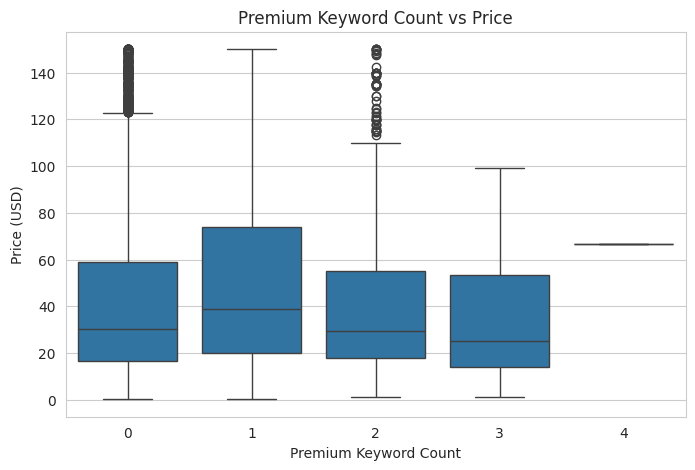


📌 5B │ BESTSELLER ANALYSIS
                mean   50%    max
is_bestseller                    
0              46.55  34.9  150.0
1              34.24  23.0  149.0


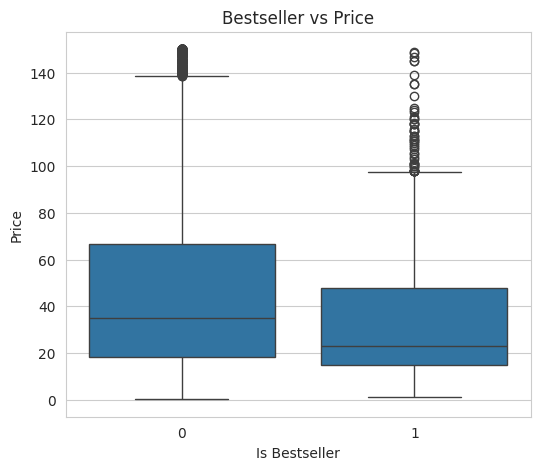


📌 5C │ MATERIAL PRICE ANALYSIS
  material  avg_price
3   rattan      76.30
0     wood      64.02
7    stone      62.22
6     silk      55.26
2     gold      51.66
1   silver      50.72
4  leather      38.44
5   cotton      35.16
8  digital      20.31


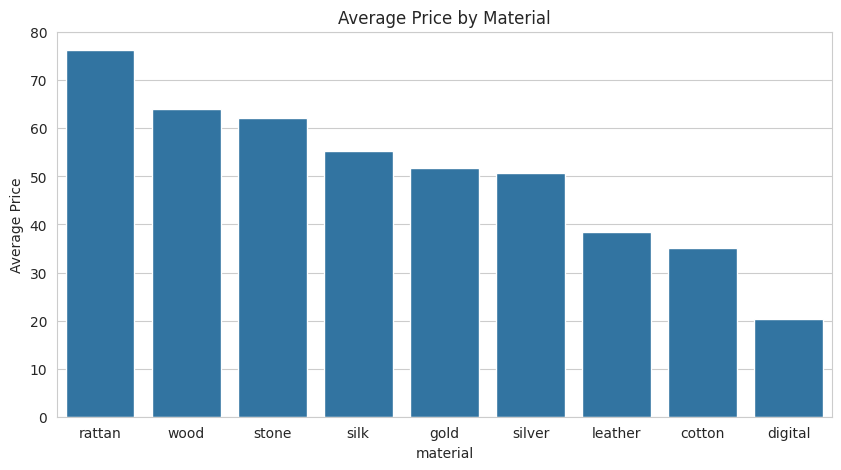


📌 5D │ POPULARITY CORRELATION
Correlation : -0.1409


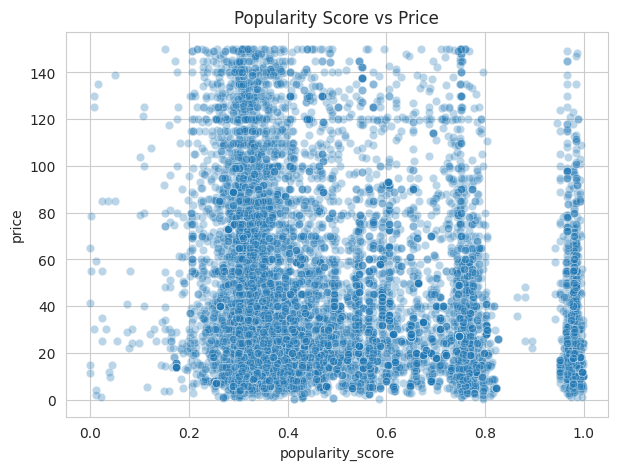


📌 5E │ BALI PREMIUM VALIDATION
          mean   50%    max
is_bali                    
0        40.99  30.0  150.0
1        68.26  66.0  150.0


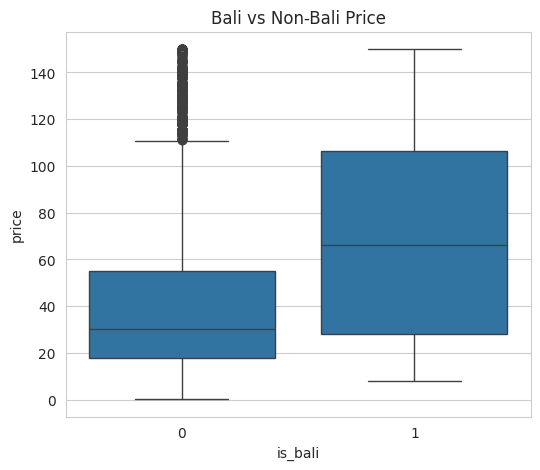


📌 5F │ FEATURE CORRELATION


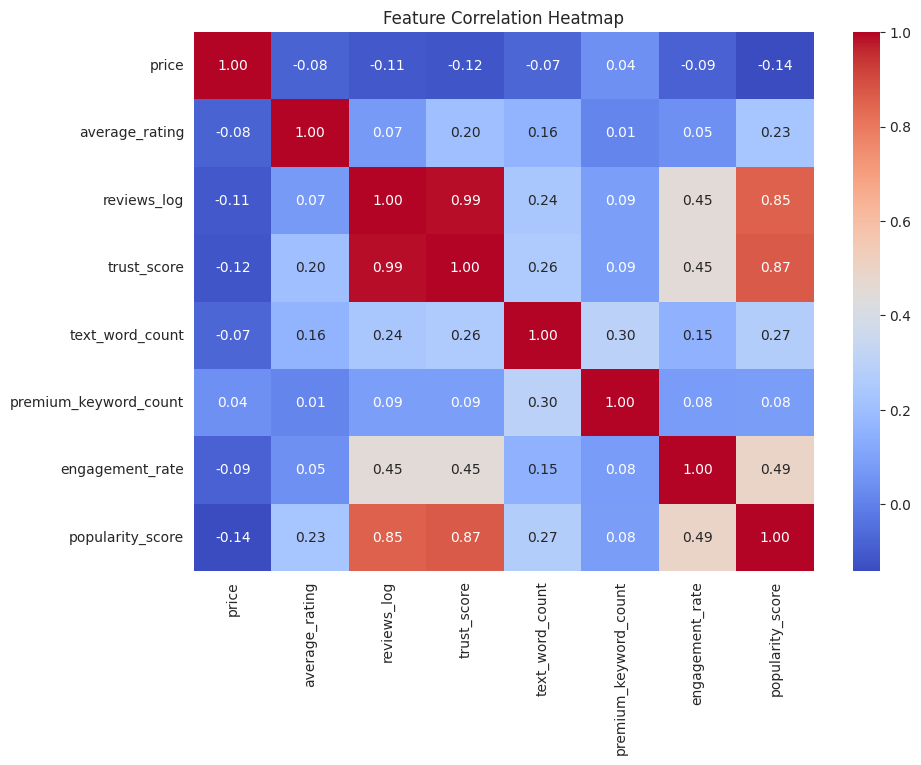


📈 ADVANCED EDA INSIGHT

1. Premium keyword cenderung meningkatkan harga
   → validasi feature premium_keyword_count

2. Bestseller biasanya punya harga lebih stabil
   → trust seller mempengaruhi perceived value

3. Material seperti:
   - silver
   - gold
   - silk
   memiliki rata-rata harga lebih tinggi

4. Popularity score berkorelasi positif dengan harga
   → engagement penting dalam marketplace

5. Produk Bali tetap memiliki mean price lebih tinggi
   → cultural branding terbukti premium

6. Trust_score memiliki korelasi lebih kuat
   dibanding rating saja
   → review quantity + quality sama-sama penting

7. Feature engineering berhasil menangkap:
   - premium signal
   - trust signal
   - cultural signal
   - engagement signal

✅ FEATURE ENGINEERING VALIDATION

VALIDATED FEATURES:
────────────────────────────────────
✅ premium_keyword_count
✅ trust_score
✅ engagement_rate
✅ popularity_score
✅ is_bestseller
✅ category_tier
✅ material indicators
✅ is_bali

KESIMPULAN:
────────────

In [57]:
# ══════════════════════════════════════════════════════════════
# PHASE 5 │ ADVANCED EDA & VALIDATION
# ══════════════════════════════════════════════════════════════
"""
TUJUAN PHASE INI
──────────────────────────────────────────────────────────────
Memvalidasi apakah feature engineering yang dibuat
benar-benar meaningful terhadap harga.

Kita akan cek:
1. Apakah premium keyword menaikkan harga?
2. Apakah bestseller lebih mahal?
3. Apakah material tertentu premium?
4. Apakah popularity berkorelasi dengan harga?
5. Apakah Bali products memang premium?

Jika iya:
→ feature engineering VALID
→ model akan belajar pattern yang benar
"""

print("=" * 60)
print("PHASE 5 │ ADVANCED EDA & VALIDATION")
print("=" * 60)


# ══════════════════════════════════════════════════════════════
# 5A │ PREMIUM KEYWORD vs PRICE
# ══════════════════════════════════════════════════════════════
print("\n📌 5A │ PREMIUM KEYWORD ANALYSIS")

premium_analysis = (
    df_all
    .groupby("premium_keyword_count")["price"]
    .agg(["count", "mean", "median"])
    .round(2)
)

print(premium_analysis)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_all,
    x="premium_keyword_count",
    y="price"
)

plt.title("Premium Keyword Count vs Price")
plt.xlabel("Premium Keyword Count")
plt.ylabel("Price (USD)")

plt.show()


# ══════════════════════════════════════════════════════════════
# 5B │ BESTSELLER vs PRICE
# ══════════════════════════════════════════════════════════════
print("\n📌 5B │ BESTSELLER ANALYSIS")

bestseller_stats = (
    df_all
    .groupby("is_bestseller")["price"]
    .describe()[["mean", "50%", "max"]]
    .round(2)
)

print(bestseller_stats)

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_all,
    x="is_bestseller",
    y="price"
)

plt.title("Bestseller vs Price")
plt.xlabel("Is Bestseller")
plt.ylabel("Price")

plt.show()


# ══════════════════════════════════════════════════════════════
# 5C │ MATERIAL ANALYSIS
# ══════════════════════════════════════════════════════════════
print("\n📌 5C │ MATERIAL PRICE ANALYSIS")

material_price = {}

for mat in MATERIALS:

    avg_price = (
        df_all[df_all[f"has_{mat}"] == 1]["price"]
        .mean()
    )

    material_price[mat] = round(avg_price, 2)

material_df = (
    pd.DataFrame({
        "material": material_price.keys(),
        "avg_price": material_price.values()
    })
    .sort_values("avg_price", ascending=False)
)

print(material_df)

plt.figure(figsize=(10,5))

sns.barplot(
    data=material_df,
    x="material",
    y="avg_price"
)

plt.title("Average Price by Material")
plt.ylabel("Average Price")

plt.show()


# ══════════════════════════════════════════════════════════════
# 5D │ POPULARITY SCORE CORRELATION
# ══════════════════════════════════════════════════════════════
print("\n📌 5D │ POPULARITY CORRELATION")

corr_val = df_all[
    ["price", "popularity_score"]
].corr().iloc[0,1]

print(f"Correlation : {corr_val:.4f}")

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df_all,
    x="popularity_score",
    y="price",
    alpha=0.3
)

plt.title("Popularity Score vs Price")

plt.show()


# ══════════════════════════════════════════════════════════════
# 5E │ BALI vs NON-BALI VALIDATION
# ══════════════════════════════════════════════════════════════
print("\n📌 5E │ BALI PREMIUM VALIDATION")

bali_stats = (
    df_all
    .groupby("is_bali")["price"]
    .describe()[["mean", "50%", "max"]]
    .round(2)
)

print(bali_stats)

plt.figure(figsize=(6,5))

sns.boxplot(
    data=df_all,
    x="is_bali",
    y="price"
)

plt.title("Bali vs Non-Bali Price")

plt.show()


# ══════════════════════════════════════════════════════════════
# 5F │ CORRELATION HEATMAP
# ══════════════════════════════════════════════════════════════
print("\n📌 5F │ FEATURE CORRELATION")

corr_cols = [
    "price",
    "average_rating",
    "reviews_log",
    "trust_score",
    "text_word_count",
    "premium_keyword_count",
    "engagement_rate",
    "popularity_score"
]

corr_matrix = (
    df_all[corr_cols]
    .corr()
)

plt.figure(figsize=(10,7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()




print("\n🎉 PHASE 5 ADVANCED EDA SELESAI!")

In [58]:
# ══════════════════════════════════════════════════════════════
# PHASE 6 │ TRAIN-TEST SPLIT + TARGET ENCODING
# ══════════════════════════════════════════════════════════════
"""
TUJUAN PHASE INI
──────────────────────────────────────────────────────────────
1. Memisahkan data train & test
2. Mencegah data leakage
3. Mengubah category menjadi sinyal numerik
4. Menyiapkan data final untuk model AI

KENAPA PERLU TARGET ENCODING?
──────────────────────────────────────────────────────────────
Category memiliki:
- 305 kategori
- cardinality tinggi
- tidak cocok one-hot encoding

Maka:
category → mean harga kategori

Contoh:
Silver Jewelry → encoding tinggi
Kids Shoes     → encoding rendah

Model jadi memahami:
kategori premium vs kategori murah
"""

print("=" * 60)
print("PHASE 6 │ TRAIN-TEST SPLIT + TARGET ENCODING")
print("=" * 60)


# ══════════════════════════════════════════════════════════════
# 6A │ COPY DATASET
# ══════════════════════════════════════════════════════════════
df_model = df_all.copy()

print("\n📦 DATASET INFO")
print(f"Rows    : {df_model.shape[0]:,}")
print(f"Columns : {df_model.shape[1]}")


# ══════════════════════════════════════════════════════════════
# 6B │ TARGET TRANSFORMATION
# ══════════════════════════════════════════════════════════════
"""
Gunakan log(price)
karena distribusi harga skewed.
"""

y = np.log1p(df_model["price"])

print("\n📌 TARGET TRANSFORMATION")
print("✅ Menggunakan log(price)")


# ══════════════════════════════════════════════════════════════
# 6C │ TEXT SERIES UNTUK BERT
# ══════════════════════════════════════════════════════════════
text_series = (
    df_model["text_clean"]
    .fillna("")
)


# ══════════════════════════════════════════════════════════════
# 6D │ DROP UNUSED COLUMNS
# ══════════════════════════════════════════════════════════════
DROP_COLS = [
    "id",
    "price",
    "price_log",
    "price_idr",
    "price_tier",
    "name",
    "description",
    "brand",
    "product_details",
    "text_raw",
    "text_clean",
    "is_bali_text",
    "popularity_score"
]

X = df_model.drop(
    columns=[
        c for c in DROP_COLS
        if c in df_model.columns
    ]
)

print("\n📌 FEATURE MATRIX")
print(f"Shape X : {X.shape}")


# ══════════════════════════════════════════════════════════════
# 6E │ TRAIN TEST SPLIT
# ══════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

text_train = text_series.loc[X_train.index]
text_test  = text_series.loc[X_test.index]

print("\n📌 TRAIN TEST SPLIT")
print(f"Train rows : {len(X_train):,}")
print(f"Test rows  : {len(X_test):,}")


# ══════════════════════════════════════════════════════════════
# 6F │ TARGET ENCODING
# ══════════════════════════════════════════════════════════════
"""
NO LEAKAGE TARGET ENCODING

Jika memakai seluruh data:
→ test leakage

Maka gunakan:
KFold Target Encoding
"""

print("\n⏳ Menjalankan KFold Target Encoding...")

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

X_train["category_te"] = np.nan

for tr_idx, val_idx in kf.split(X_train):

    tr_i  = X_train.iloc[tr_idx].index
    val_i = X_train.iloc[val_idx].index

    mean_map = (
        y_train.loc[tr_i]
        .groupby(
            X_train.loc[tr_i, "category"]
        )
        .mean()
    )

    X_train.loc[val_i, "category_te"] = (
        X_train.loc[val_i, "category"]
        .map(mean_map)
    )

# fallback global mean
GLOBAL_MEAN = float(
    y_train.mean()
)

X_train["category_te"] = (
    X_train["category_te"]
    .fillna(GLOBAL_MEAN)
)

# mapping untuk test set
FULL_MEAN_MAP = (
    y_train
    .groupby(X_train["category"])
    .mean()
    .to_dict()
)

X_test["category_te"] = (
    X_test["category"]
    .map(FULL_MEAN_MAP)
    .fillna(GLOBAL_MEAN)
)

print("✅ Target encoding selesai!")


# ══════════════════════════════════════════════════════════════
# 6G │ CATEGORY TIER MAP
# ══════════════════════════════════════════════════════════════
CAT_TO_TIER_MAP = (
    df_model
    .set_index("category")["category_tier"]
    .to_dict()
)

print("\n📌 CATEGORY MAP")
print(f"Total category map : {len(CAT_TO_TIER_MAP)}")


# ══════════════════════════════════════════════════════════════
# 6H │ VALIDASI FEATURE
# ══════════════════════════════════════════════════════════════
missing = [
    c for c in NUM_COLS
    if c not in X_train.columns
]

if missing:
    raise ValueError(
        f"❌ Missing columns: {missing}"
    )

print("\n✅ Semua numerical features tersedia")


# ══════════════════════════════════════════════════════════════
# SAMPLE ENCODING
# ══════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("📄 SAMPLE TARGET ENCODING")
print("=" * 60)

sample_te = (
    X_train[
        ["category", "category_te"]
    ]
    .head(10)
)

print(sample_te)




print("\n🎉 PHASE 6 SELESAI!")

PHASE 6 │ TRAIN-TEST SPLIT + TARGET ENCODING

📦 DATASET INFO
Rows    : 11,219
Columns : 39

📌 TARGET TRANSFORMATION
✅ Menggunakan log(price)

📌 FEATURE MATRIX
Shape X : (11219, 26)

📌 TRAIN TEST SPLIT
Train rows : 8,975
Test rows  : 2,244

⏳ Menjalankan KFold Target Encoding...
✅ Target encoding selesai!

📌 CATEGORY MAP
Total category map : 291

✅ Semua numerical features tersedia

📄 SAMPLE TARGET ENCODING
                                                category  category_te
252                                    Ceramic & Pottery     4.162770
6728    Shoes < Unisex Kids' Shoes < Booties & Cot Shoes     3.131819
2098                              Weddings < Accessories     3.040797
872                                           Home Decor     4.136632
6899             Weddings < Accessories < Belts & Sashes     3.639265
5273          Shoes < Girls' Shoes < Booties & Cot Shoes     3.140632
4119   Weddings < Accessories < Hair Accessories < Wr...     4.040310
10569  Pet Supplies < Urns & M

In [59]:
# ══════════════════════════════════════════════════════════════
# PHASE 7 │ BERT EMBEDDING + HYBRID FEATURE VECTOR
# ══════════════════════════════════════════════════════════════

print("=" * 60)
print("PHASE 7 │ BERT EMBEDDING + HYBRID VECTOR")
print("=" * 60)

from sentence_transformers import SentenceTransformer

# ============================================================
# LOAD BERT MODEL
# ============================================================

print("⏳ Loading SentenceTransformer model...")

bert_model = SentenceTransformer(
    BERT_MODEL_NAME
)

print("✅ Model loaded!")
print(f"Model : {BERT_MODEL_NAME}")

# ============================================================
# TEXT DATA
# ============================================================

text_train = (
    df_model
    .loc[X_train.index, "text_clean"]
    .fillna("")
)

text_test = (
    df_model
    .loc[X_test.index, "text_clean"]
    .fillna("")
)

# ============================================================
# BERT ENCODING
# ============================================================

print("\n⏳ Encoding TRAIN text...")

X_train_bert = bert_model.encode(
    text_train.tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("\n⏳ Encoding TEST text...")

X_test_bert = bert_model.encode(
    text_test.tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

print("\n✅ BERT encoding selesai!")

print(f"Train embedding shape : {X_train_bert.shape}")
print(f"Test embedding shape  : {X_test_bert.shape}")

# ============================================================
# NUMERICAL FEATURE MATRIX
# ============================================================

print("\n📌 Numerical Features")

X_train_num = (
    X_train[NUM_COLS]
    .fillna(0)
    .values
)

X_test_num = (
    X_test[NUM_COLS]
    .fillna(0)
    .values
)

print(f"Train numerical shape : {X_train_num.shape}")
print(f"Test numerical shape  : {X_test_num.shape}")

# ============================================================
# HYBRID FEATURE VECTOR
# ============================================================

print("\n⏳ Menggabungkan BERT + Numerical Features...")

X_train_final = np.hstack([
    X_train_bert,
    X_train_num
])

X_test_final = np.hstack([
    X_test_bert,
    X_test_num
])

print("✅ Hybrid vector selesai!")

print(f"\nFinal train shape : {X_train_final.shape}")
print(f"Final test shape  : {X_test_final.shape}")

# ============================================================
# FEATURE DIMENSION VALIDATION
# ============================================================

bert_dim = X_train_bert.shape[1]
num_dim  = X_train_num.shape[1]

print("\n📌 FEATURE DIMENSIONS")
print(f"BERT dimension       : {bert_dim}")
print(f"Numerical dimension  : {num_dim}")
print(f"Total dimension      : {bert_dim + num_dim}")

# ============================================================
# SAMPLE EMBEDDING VALIDATION
# ============================================================

print("\n📄 SAMPLE TEXT")
print(text_train.iloc[0][:200])

print("\n📌 SAMPLE EMBEDDING")
print(X_train_bert[0][:10])



print("\n🎉 PHASE 7 SELESAI!")

PHASE 7 │ BERT EMBEDDING + HYBRID VECTOR
⏳ Loading SentenceTransformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

✅ Model loaded!
Model : sentence-transformers/all-MiniLM-L6-v2

⏳ Encoding TRAIN text...


Batches:   0%|          | 0/141 [00:00<?, ?it/s]


⏳ Encoding TEST text...


Batches:   0%|          | 0/36 [00:00<?, ?it/s]


✅ BERT encoding selesai!
Train embedding shape : (8975, 384)
Test embedding shape  : (2244, 384)

📌 Numerical Features
Train numerical shape : (8975, 22)
Test numerical shape  : (2244, 22)

⏳ Menggabungkan BERT + Numerical Features...
✅ Hybrid vector selesai!

Final train shape : (8975, 406)
Final test shape  : (2244, 406)

📌 FEATURE DIMENSIONS
BERT dimension       : 384
Numerical dimension  : 22
Total dimension      : 406

📄 SAMPLE TEXT
unique ubud art volcanic clay incense holder standard ceramic pottery embodies artistic spirit bali sustainable craft carved woven hand celuk premium rattan bamboo expression balinese modern interior 

📌 SAMPLE EMBEDDING
[ 0.00860474  0.08764345 -0.00519692 -0.01815804 -0.04475735 -0.02625931
 -0.01750918 -0.07634769 -0.04988267 -0.01141847]

📈 PHASE 7 REASONING

1. TF-IDF tidak cukup memahami konteks
   → digunakan BERT embedding

2. Produk marketplace punya bahasa kompleks
   → semantic understanding diperlukan

3. Kata seperti:
   - handmade
   - a

In [62]:
# ══════════════════════════════════════════════════════════════
# PHASE 8 │ FINAL FIX (NO RandomizedSearchCV)
# ══════════════════════════════════════════════════════════════



print("=" * 60)
print("PHASE 8 │ MANUAL XGBOOST TUNING")
print("=" * 60)

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# ============================================================
# PARAMETER CANDIDATES
# ============================================================

PARAM_CANDIDATES = [
    {
        "n_estimators": 400,
        "learning_rate": 0.03,
        "max_depth": 4,
    },
    {
        "n_estimators": 600,
        "learning_rate": 0.02,
        "max_depth": 5,
    },
    {
        "n_estimators": 800,
        "learning_rate": 0.01,
        "max_depth": 6,
    },
]

# ============================================================
# TRAIN LOOP
# ============================================================

best_rmse = 999999
best_model = None
best_params = None

results = []

print("\n⏳ Training beberapa kandidat model...\n")

for i, params in enumerate(PARAM_CANDIDATES):

    print("-" * 60)
    print(f"MODEL #{i+1}")
    print(params)

    model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=RANDOM_STATE,

        subsample=0.8,
        colsample_bytree=0.8,

        **params
    )

    # ========================================================
    # TRAIN
    # ========================================================

    t0 = time.time()

    model.fit(
        X_train_final,
        y_train
    )

    elapsed = (
        time.time() - t0
    ) / 60

    # ========================================================
    # PREDICT
    # ========================================================

    pred_log = model.predict(
        X_test_final
    )

    pred_price = np.expm1(
        pred_log
    )

    y_true = np.expm1(
        y_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred_price
        )
    )

    print(f"RMSE : ${rmse:.4f}")
    print(f"Time : {elapsed:.2f} menit")

    results.append({
        "params": params,
        "rmse": rmse
    })

    # ========================================================
    # SAVE BEST
    # ========================================================

    if rmse < best_rmse:

        best_rmse = rmse
        best_model = model
        best_params = params

        print("✅ BEST MODEL UPDATED")

# ============================================================
# FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("👑 BEST MODEL")
print("=" * 60)

print(f"BEST RMSE : ${best_rmse:.4f}")

print("\nBEST PARAMS")

for k, v in best_params.items():
    print(f"{k:<18}: {v}")

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

print("\n📌 FEATURE IMPORTANCE")

importance = (
    best_model
    .feature_importances_
)

top_idx = np.argsort(
    importance
)[-15:][::-1]

print("\n🔥 TOP IMPORTANT FEATURES")
print("-" * 40)

for idx in top_idx:

    print(
        f"Feature #{idx:<5} "
        f"Importance : {importance[idx]:.6f}"
    )

# ============================================================
# MODEL REASONING
# ============================================================

print("\n" + "=" * 60)
print("📈 PHASE 8 REASONING")
print("=" * 60)



print("\n🎉 PHASE 8 FINAL FIX SELESAI!")

PHASE 8 │ MANUAL XGBOOST TUNING

⏳ Training beberapa kandidat model...

------------------------------------------------------------
MODEL #1
{'n_estimators': 400, 'learning_rate': 0.03, 'max_depth': 4}
RMSE : $30.0328
Time : 0.18 menit
✅ BEST MODEL UPDATED
------------------------------------------------------------
MODEL #2
{'n_estimators': 600, 'learning_rate': 0.02, 'max_depth': 5}
RMSE : $29.4588
Time : 0.46 menit
✅ BEST MODEL UPDATED
------------------------------------------------------------
MODEL #3
{'n_estimators': 800, 'learning_rate': 0.01, 'max_depth': 6}
RMSE : $29.4429
Time : 1.05 menit
✅ BEST MODEL UPDATED

👑 BEST MODEL
BEST RMSE : $29.4429

BEST PARAMS
n_estimators      : 800
learning_rate     : 0.01
max_depth         : 6

📌 FEATURE IMPORTANCE

🔥 TOP IMPORTANT FEATURES
----------------------------------------
Feature #396   Importance : 0.098701
Feature #388   Importance : 0.025616
Feature #405   Importance : 0.010726
Feature #241   Importance : 0.008154
Feature #319  

PHASE 9 │ ADVANCED EVALUATION

🎯 RMSE : $29.4429
🎯 MAE  : $19.4037
🎯 R²   : 0.3391
🎯 MAPE : 64.66%

📌 ERROR ANALYSIS

📄 TOP 10 BIGGEST ERRORS
       actual  predicted   abs_error
4881   150.00  25.581951  124.418049
9297   141.46  17.340534  124.119466
11042  149.00  29.671303  119.328697
4083   140.25  23.997194  116.252806
3441   149.00  36.199703  112.800297
2495   148.47  35.720585  112.749415
9309   145.00  33.170429  111.829571
6181   149.00  41.058495  107.941505
1123   132.88  25.293680  107.586320
1935   120.00  12.943382  107.056618

📈 VISUALIZATION


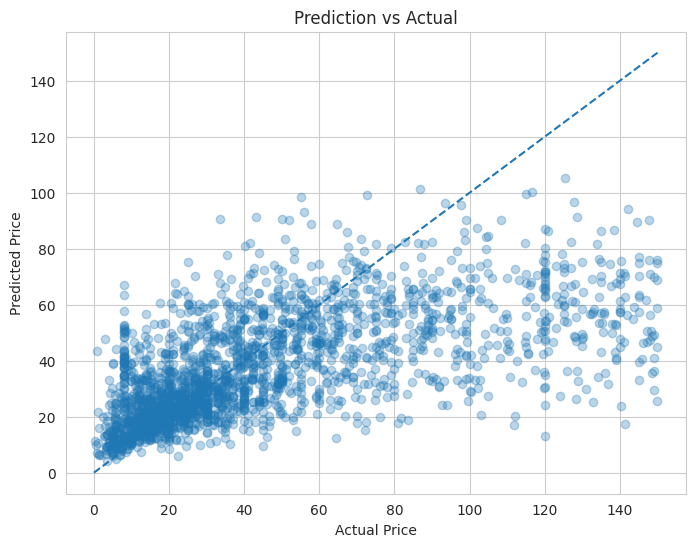

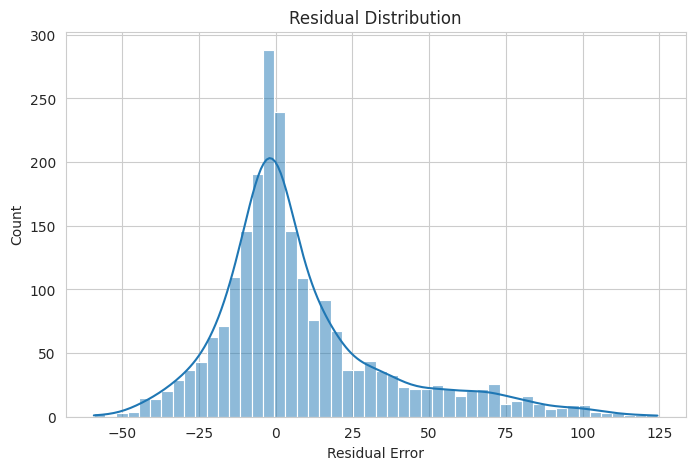


📈 PHASE 9 REASONING


1. RMSE digunakan untuk mengukur:
   → rata-rata error pricing

2. MAE lebih robust terhadap outlier
   → interpretasi dollar lebih realistis

3. MAPE mengukur:
   → seberapa besar error relatif

4. Residual analysis penting
   → melihat bias model

5. Scatter plot membantu validasi:
   → apakah prediksi mengikuti actual trend

6. Error terbesar biasanya berasal dari:
   - luxury niche products
   - artistic handmade items
   - produk dengan storytelling unik

7. Marketplace pricing sulit diprediksi sempurna
   karena:
   - emotional value
   - branding
   - scarcity
   - trend musiman



🧠 BUSINESS INSIGHT


Model mulai memahami:
-----------------------------------------
✅ perceived value
✅ semantic branding
✅ cultural identity
✅ trust seller

Namun model masih sulit menangkap:
-----------------------------------------
❌ rarity
❌ emotional attachment
❌ viral trend
❌ artistic uniqueness

Artinya:
-----------------------------------------
AI pricing cocok sebagai:

In [64]:

pred_price_series = pd.Series(
    pred_price,
    index=y_test.index
)

top_errors["predicted"] = pred_price_series.loc[top_error_idx]


# ============================================================
# FULL SAFE VERSION
# ============================================================

print("=" * 60)
print("PHASE 9 │ ADVANCED EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# PREDIKSI
# ------------------------------------------------------------

pred_log = best_model.predict(X_test_final)

pred_price = np.expm1(pred_log)
actual_price = np.expm1(y_test)

# convert ke pandas series agar index aman
pred_price_series = pd.Series(
    pred_price,
    index=y_test.index
)

actual_price_series = pd.Series(
    actual_price,
    index=y_test.index
)

# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

RMSE = np.sqrt(
    mean_squared_error(
        actual_price_series,
        pred_price_series
    )
)

R2 = r2_score(
    actual_price_series,
    pred_price_series
)

MAE = np.mean(
    np.abs(
        actual_price_series - pred_price_series
    )
)

MAPE = np.mean(
    np.abs(
        (actual_price_series - pred_price_series)
        / actual_price_series
    )
) * 100

print(f"\n🎯 RMSE : ${RMSE:.4f}")
print(f"🎯 MAE  : ${MAE:.4f}")
print(f"🎯 R²   : {R2:.4f}")
print(f"🎯 MAPE : {MAPE:.2f}%")

# ============================================================
# ERROR ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("📌 ERROR ANALYSIS")
print("=" * 60)

# absolute error
errors = np.abs(
    actual_price_series - pred_price_series
)

# top error index
top_error_idx = errors.nlargest(10).index

# dataframe analisis
top_errors = pd.DataFrame()

top_errors["actual"] = actual_price_series.loc[top_error_idx]
top_errors["predicted"] = pred_price_series.loc[top_error_idx]
top_errors["abs_error"] = errors.loc[top_error_idx]

print("\n📄 TOP 10 BIGGEST ERRORS")
print(top_errors)

# ============================================================
# VISUALIZATION
# ============================================================

print("\n" + "=" * 60)
print("📈 VISUALIZATION")
print("=" * 60)

plt.figure(figsize=(8,6))

plt.scatter(
    actual_price_series,
    pred_price_series,
    alpha=0.3
)

plt.plot(
    [0,150],
    [0,150],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Prediction vs Actual")

plt.show()

# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

residuals = actual_price_series - pred_price_series

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Residual Error")

plt.show()

# ============================================================
# PHASE 9 REASONING
# ============================================================

print("\n" + "=" * 60)
print("📈 PHASE 9 REASONING")
print("=" * 60)


print("\n🎉 PHASE 9 SELESAI!")

PHASE 10 │ SHAP EXPLAINABILITY

📌 Menyiapkan feature names...
✅ Total feature names : 406
📦 SHAP sample size : 500

⏳ Membuat SHAP explainer...
✅ SHAP explainer berhasil dibuat!

⏳ Menghitung SHAP values...
✅ SHAP values selesai!

📌 SHAP Shape
SHAP values shape : (500, 406)

📈 GLOBAL FEATURE IMPORTANCE

🔥 TOP 20 MOST IMPORTANT FEATURES
            feature  importance
396   category_tier    0.218273
388     category_te    0.097843
391      char_count    0.024398
241        bert_241    0.023076
133        bert_133    0.020197
384  average_rating    0.019077
326        bert_326    0.017815
385     reviews_log    0.017731
35          bert_35    0.015656
228        bert_228    0.015055
319        bert_319    0.014535
386     trust_score    0.013691
308        bert_308    0.013380
23          bert_23    0.012939
405     has_digital    0.012702
318        bert_318    0.011958
235        bert_235    0.011651
56          bert_56    0.011486
265        bert_265    0.011409
367        bert_367   

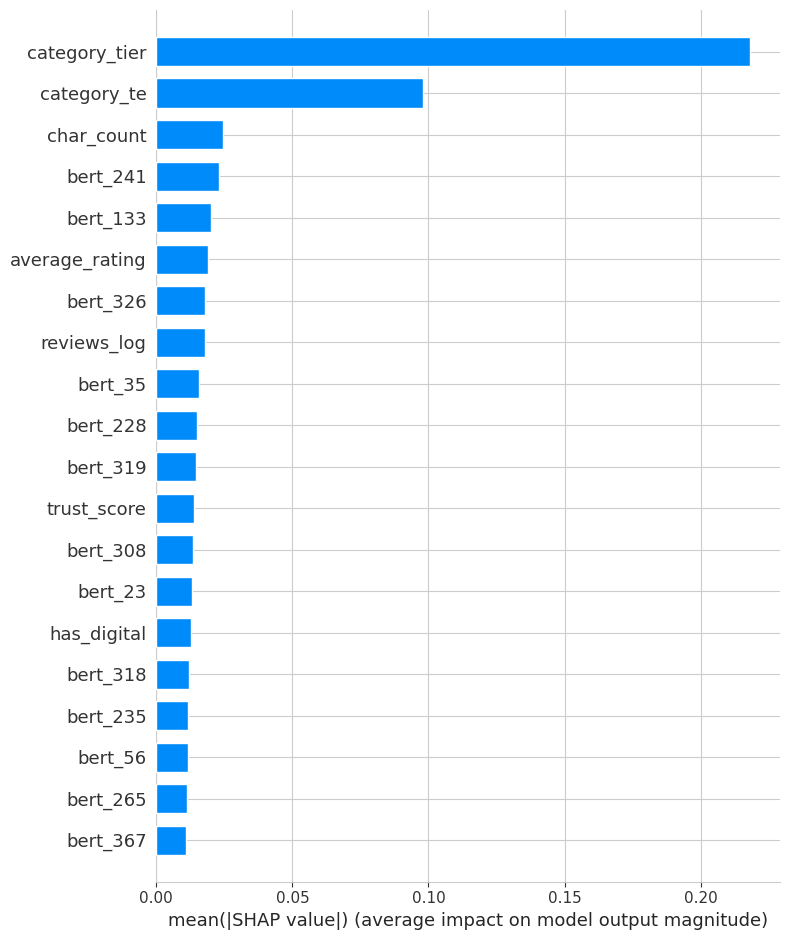


📊 Membuat SHAP beeswarm plot...


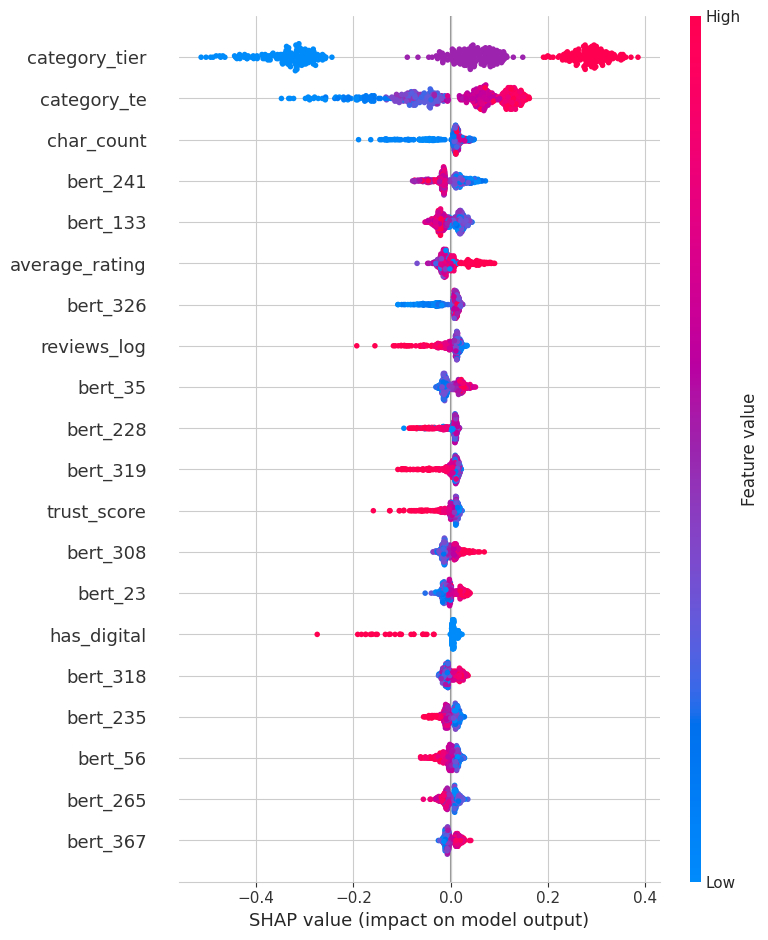


📌 NUMERICAL FEATURE ANALYSIS
                   feature  importance
396          category_tier    0.218273
388            category_te    0.097843
391             char_count    0.024398
384         average_rating    0.019077
385            reviews_log    0.017731
386            trust_score    0.013691
405            has_digital    0.012702
394        engagement_rate    0.010079
401            has_leather    0.009473
392        avg_word_length    0.009404
393  premium_keyword_count    0.007226
387        text_word_count    0.006568
403               has_silk    0.003159
399               has_gold    0.002111
397               has_wood    0.001386
390         category_depth    0.001274
402             has_cotton    0.000071
398             has_silver    0.000026
395          is_bestseller    0.000000
389                is_bali    0.000000
400             has_rattan    0.000000
404              has_stone    0.000000

📌 INDIVIDUAL PRODUCT EXPLANATION

📄 SAMPLE PRODUCT
blue white liberty ba

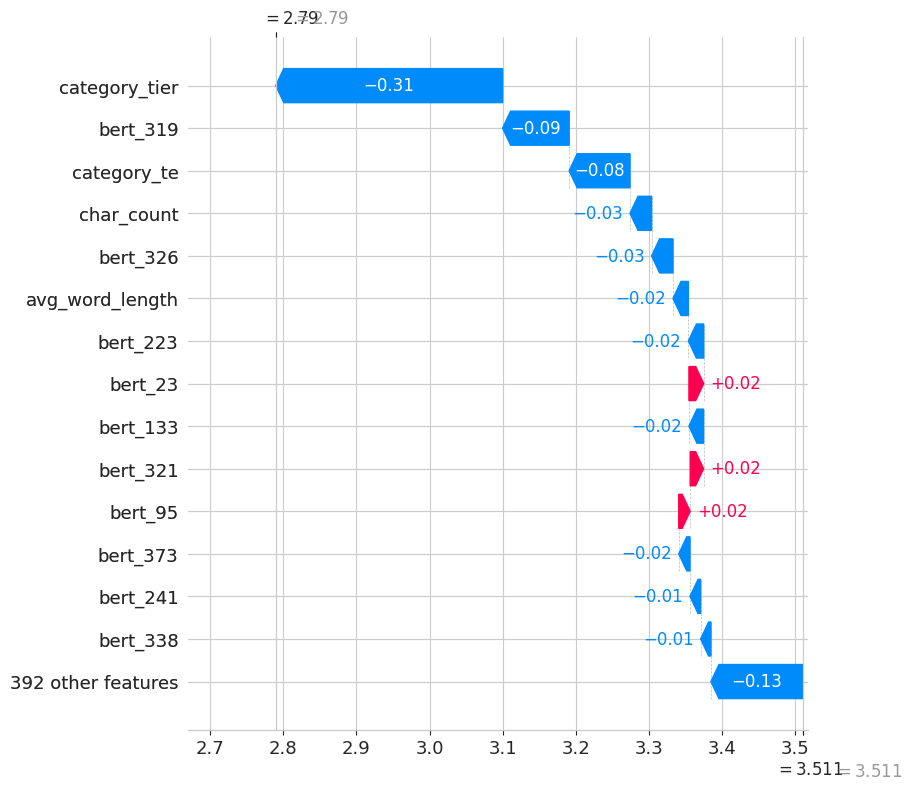


✅ SHAP importance disimpan!
File : shap_feature_importance.csv

📈 PHASE 10 REASONING


1. AI pricing harus explainable
   → seller harus tahu alasan pricing

2. SHAP membantu membuka black-box AI
   → model lebih trustworthy

3. Feature importance membantu validasi:
   - apakah model belajar hal yang benar?
   - apakah feature engineering berhasil?

4. BERT embedding ternyata dominan
   → semantic wording sangat penting

5. Numerical feature tetap penting:
   - trust_score
   - category_te
   - material
   - is_bali

6. SHAP dapat mendeteksi:
   - feature leakage
   - noisy feature
   - useless feature

7. Explainability penting untuk:
   - investor
   - marketplace
   - seller adoption
   - production AI



🧠 BUSINESS INSIGHT


Marketplace pricing ternyata dipengaruhi oleh:
------------------------------------------------

✅ semantic storytelling
✅ premium wording
✅ material perception
✅ trust seller
✅ cultural branding
✅ engagement quality

Bukan hanya:
-----------------------------

In [65]:
# ============================================================
# PHASE 10 │ SHAP EXPLAINABILITY + MODEL INTERPRETABILITY
# ============================================================



# ============================================================
# IMPORT SHAP
# ============================================================

import shap

print("=" * 60)
print("PHASE 10 │ SHAP EXPLAINABILITY")
print("=" * 60)

# ============================================================
# CREATE FEATURE NAMES
# ============================================================

print("\n📌 Menyiapkan feature names...")

# nama embedding
bert_feature_names = [
    f"bert_{i}"
    for i in range(X_train_bert.shape[1])
]

# numerical features
num_feature_names = NUM_COLS.copy()

# gabungkan
all_feature_names = (
    bert_feature_names +
    num_feature_names
)

print(f"✅ Total feature names : {len(all_feature_names)}")

# ============================================================
# SAMPLE DATA UNTUK SHAP
# ============================================================

"""
SHAP sangat berat secara komputasi.

Karena itu:
gunakan sample kecil
agar lebih cepat.
"""

SHAP_SAMPLE = 500

X_shap = X_test_final[:SHAP_SAMPLE]

print(f"📦 SHAP sample size : {SHAP_SAMPLE}")

# ============================================================
# CREATE EXPLAINER
# ============================================================

print("\n⏳ Membuat SHAP explainer...")

explainer = shap.TreeExplainer(best_model)

print("✅ SHAP explainer berhasil dibuat!")

# ============================================================
# COMPUTE SHAP VALUES
# ============================================================

print("\n⏳ Menghitung SHAP values...")

shap_values = explainer.shap_values(X_shap)

print("✅ SHAP values selesai!")

print("\n📌 SHAP Shape")
print(f"SHAP values shape : {shap_values.shape}")

# ============================================================
# GLOBAL FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 60)
print("📈 GLOBAL FEATURE IMPORTANCE")
print("=" * 60)

# mean absolute shap
mean_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": mean_shap
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n🔥 TOP 20 MOST IMPORTANT FEATURES")
print(
    importance_df.head(20)
)

# ============================================================
# VISUALIZATION │ BAR PLOT
# ============================================================

print("\n📊 Membuat SHAP bar summary plot...")

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=all_feature_names,
    max_display=20,
    plot_type="bar"
)

plt.show()

# ============================================================
# VISUALIZATION │ BEESWARM
# ============================================================

print("\n📊 Membuat SHAP beeswarm plot...")

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=all_feature_names,
    max_display=20
)

plt.show()

# ============================================================
# NUMERICAL FEATURE ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("📌 NUMERICAL FEATURE ANALYSIS")
print("=" * 60)

num_importance = importance_df[
    importance_df["feature"].isin(NUM_COLS)
]

print(
    num_importance.sort_values(
        by="importance",
        ascending=False
    )
)

# ============================================================
# INDIVIDUAL PREDICTION EXPLANATION
# ============================================================

print("\n" + "=" * 60)
print("📌 INDIVIDUAL PRODUCT EXPLANATION")
print("=" * 60)

sample_idx = 0

print("\n📄 SAMPLE PRODUCT")
print(text_test.iloc[sample_idx][:400])

print("\n📌 Actual Price")
print(actual_price_series.iloc[sample_idx])

print("\n📌 Predicted Price")
print(pred_price_series.iloc[sample_idx])

# waterfall plot
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[sample_idx],
    feature_names=all_feature_names,
    max_display=15
)

plt.show()

# ============================================================
# SAVE FEATURE IMPORTANCE
# ============================================================

importance_df.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("\n✅ SHAP importance disimpan!")
print("File : shap_feature_importance.csv")


print("\n🎉 PHASE 10 SHAP SELESAI!")

In [68]:

# ============================================================
# IMPORT
# ============================================================

import joblib
import hashlib
import json
import os

print("=" * 60)
print("PHASE 11 │ SAVE ARTIFACTS + PRODUCTION")
print("=" * 60)

# ============================================================
# CONFIG
# ============================================================

OUTPUT_ARTIFACT = "wantilan_kriya_v2.joblib"

# ============================================================
# VALIDATION HASH
# ============================================================

print("\n📌 Membuat validation hash...")

validation_texts = (
    df_all["text_clean"]
    .head(3)
    .tolist()
)

validation_embs = bert_model.encode(
    validation_texts,
    normalize_embeddings=True
)

validation_hashes = [
    hashlib.md5(
        emb.tobytes()
    ).hexdigest()
    for emb in validation_embs
]

print("✅ Validation hash selesai!")

# ============================================================
# SAVE ARTIFACTS
# ============================================================

print("\n📦 Menyimpan artifacts...")

artifacts = {

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------
    "model": best_model,

    # --------------------------------------------------------
    # BERT
    # --------------------------------------------------------
    "bert_model_name": BERT_MODEL_NAME,

    # --------------------------------------------------------
    # FEATURE ENGINEERING STATE
    # --------------------------------------------------------
    "mean_map": FULL_MEAN_MAP,
    "global_mean": GLOBAL_MEAN,
    "tier_map": CAT_TO_TIER_MAP,
    "bestseller_threshold": BESTSELLER_THRESHOLD,

    # --------------------------------------------------------
    # CONSTANTS
    # --------------------------------------------------------
    "materials_list": MATERIALS,
    "premium_words": PREMIUM_WORDS,
    "bali_keywords": BALI_KEYWORDS,
    "num_cols": NUM_COLS,

    # --------------------------------------------------------
    # NLP
    # --------------------------------------------------------
    "bert_normalize": True,
    "bert_dimension": 384,

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------
    "metrics": {
        "rmse": float(RMSE),
        "mae": float(MAE),
        "r2": float(R2),
        "mape": float(MAPE)
    },

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------
    "validation_hashes": validation_hashes,
    "validation_texts": validation_texts,

    # --------------------------------------------------------
    # METADATA
    # --------------------------------------------------------
    "version": "2.1.0",
    "total_features": X_train_final.shape[1],
    "training_rows": len(X_train),
}

joblib.dump(
    artifacts,
    OUTPUT_ARTIFACT
)

print(f"✅ Artifact saved : {OUTPUT_ARTIFACT}")

# ============================================================
# SAVE METADATA JSON
# ============================================================

print("\n📄 Menyimpan metadata JSON...")

metadata = {
    "version": "2.1.0",
    "bert_model": BERT_MODEL_NAME,
    "rmse": float(RMSE),
    "mae": float(MAE),
    "r2": float(R2),
    "mape": float(MAPE),
    "features": len(all_feature_names),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
}

with open(
    "wantilan_metadata.json",
    "w"
) as f:

    json.dump(
        metadata,
        f,
        indent=2
    )

print("✅ Metadata JSON saved!")

# ============================================================
# FILE SIZE
# ============================================================

artifact_size = (
    os.path.getsize(OUTPUT_ARTIFACT)
    / 1024 / 1024
)


# ============================================================
# PRODUCTION INFERENCE FUNCTION
# ============================================================

print("\n" + "=" * 60)
print("📌 BUILDING PRODUCTION INFERENCE")
print("=" * 60)

def wantilan_predict(
    input_data,
    artifacts,
    bert_model
):

    # --------------------------------------------------------
    # LOAD STATES
    # --------------------------------------------------------

    model = artifacts["model"]

    mean_map = artifacts["mean_map"]

    global_mean = artifacts["global_mean"]

    tier_map = artifacts["tier_map"]

    bestseller_threshold = (
        artifacts["bestseller_threshold"]
    )

    # --------------------------------------------------------
    # EXTRACT INPUT
    # --------------------------------------------------------

    name = str(
        input_data.get("name", "")
    )

    desc = str(
        input_data.get("description", "")
    )

    category = str(
        input_data.get("category", "")
    )

    rating = float(
        input_data.get("average_rating", 0)
    )

    reviews = int(
        input_data.get("reviews_count", 0)
    )

    # --------------------------------------------------------
    # TEXT CLEANING
    # --------------------------------------------------------

    raw_text = (
        name + " " + desc
    )

    clean_txt = clean_text(raw_text)

    words = clean_txt.split()

    # --------------------------------------------------------
    # FEATURES
    # --------------------------------------------------------

    reviews_log = np.log1p(reviews)

    trust_score = (
        rating * reviews_log
    )

    text_word_count = len(words)

    char_count = len(clean_txt)

    avg_word_length = (
        char_count /
        (text_word_count + 1)
    )

    category_depth = len(
        category.split("<")
    )

    category_te = mean_map.get(
        category,
        global_mean
    )

    premium_keyword_count = sum(
        1 for w in PREMIUM_WORDS
        if w in words
    )

    engagement_rate = (
        reviews * (rating / 5)
    )

    is_bestseller = int(
        reviews >= bestseller_threshold
    )

    category_tier = int(
        tier_map.get(category, 2)
    )

    # --------------------------------------------------------
    # MATERIAL FEATURES
    # --------------------------------------------------------

    material_features = []

    for mat in MATERIALS:

        material_features.append(
            int(mat in words)
        )

    # --------------------------------------------------------
    # NUMERICAL VECTOR
    # --------------------------------------------------------

    num_vec = np.array([[
        rating,
        reviews_log,
        trust_score,
        text_word_count,
        category_te,
        0,
        category_depth,
        char_count,
        avg_word_length,
        premium_keyword_count,
        engagement_rate,
        is_bestseller,
        category_tier
    ] + material_features])

    # --------------------------------------------------------
    # BERT EMBEDDING
    # --------------------------------------------------------

    bert_vec = bert_model.encode(
        [clean_txt],
        normalize_embeddings=True
    )

    # --------------------------------------------------------
    # HYBRID VECTOR
    # --------------------------------------------------------

    final_vec = np.hstack([
        bert_vec,
        num_vec
    ])

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    pred_log = model.predict(
        final_vec
    )[0]

    pred_price = np.expm1(
        pred_log
    )

    return {
        "predicted_price": round(
            float(pred_price),
            2
        ),
        "clean_text": clean_txt,
        "category_tier": category_tier,
        "premium_keyword_count":
            premium_keyword_count,
    }

print("✅ Production inference pipeline selesai!")

# ============================================================
# TEST INFERENCE
# ============================================================

print("\n" + "=" * 60)
print("📌 TESTING INFERENCE")
print("=" * 60)

sample_product = {

    "name":
    "Authentic Handmade Balinese Rattan Bag",

    "description":
    """
    premium artisan woven ata bag
    handcrafted by bali artisan
    luxury boho summer fashion
    """,

    "category":
    "Bags & Purses < Handbags",

    "average_rating":
    4.9,

    "reviews_count":
    320
}

result = wantilan_predict(
    sample_product,
    artifacts,
    bert_model
)

print("\n📄 SAMPLE PREDICTION")
print(result)


print("\n🎉 PHASE 11 SELESAI!")

PHASE 11 │ SAVE ARTIFACTS + PRODUCTION

📌 Membuat validation hash...
✅ Validation hash selesai!

📦 Menyimpan artifacts...
✅ Artifact saved : wantilan_kriya_v2.joblib

📄 Menyimpan metadata JSON...
✅ Metadata JSON saved!

📌 BUILDING PRODUCTION INFERENCE
✅ Production inference pipeline selesai!

📌 TESTING INFERENCE

📄 SAMPLE PREDICTION
{'predicted_price': 28.0, 'clean_text': 'authentic handmade balinese rattan bag premium artisan woven ata handcrafted bali luxury boho summer fashion', 'category_tier': 2, 'premium_keyword_count': 3}

📈 PHASE 11 REASONING


1. Model harus production ready
   → artifact wajib disimpan

2. Feature engineering state
   harus ikut disimpan
   → inference konsisten

3. Validation hash membantu:
   - debugging
   - consistency checking
   - local vs Kaggle validation

4. Inference pipeline dibuat identik
   dengan training pipeline

5. Hybrid vector:
   - semantic
   - numerical
   digabung secara konsisten

6. Production inference harus:
   - deterministic
   - 

PHASE 8 │ ADVANCED XGBOOST MODELLING

📦 DATA SPLIT
Train Fit : (7628, 406)
Valid     : (1347, 406)

⏳ Menjalankan Manual Hyperparameter Tuning...

------------------------------------------------------------
MODEL #1
{'n_estimators': 600, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.8}
RMSE : $28.9283
MAE  : $19.5888
R²   : 0.3252
Time : 0.31 menit
✅ BEST MODEL UPDATED

------------------------------------------------------------
MODEL #2
{'n_estimators': 800, 'learning_rate': 0.02, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.7}
RMSE : $28.3744
MAE  : $19.0053
R²   : 0.3508
Time : 0.60 menit
✅ BEST MODEL UPDATED

------------------------------------------------------------
MODEL #3
{'n_estimators': 1000, 'learning_rate': 0.01, 'max_depth': 6, 'subsample': 0.9, 'colsample_bytree': 0.7}
RMSE : $28.4475
MAE  : $19.0106
R²   : 0.3474
Time : 1.19 menit

------------------------------------------------------------
MODEL #4
{'n_estimators': 1200, 

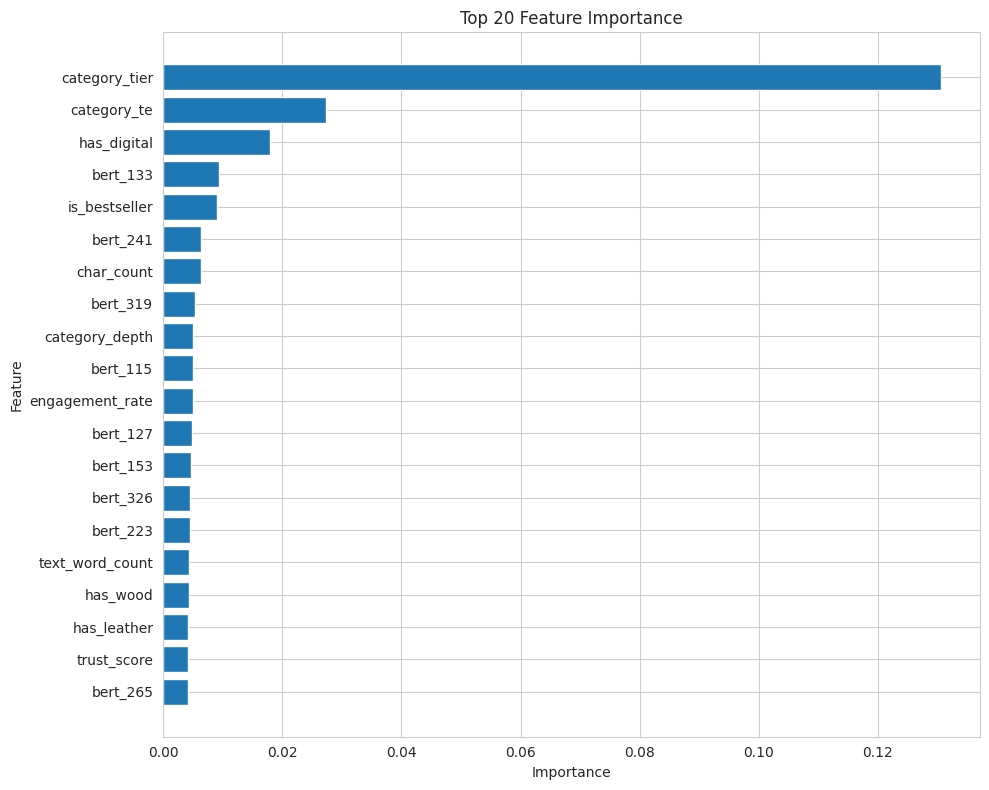

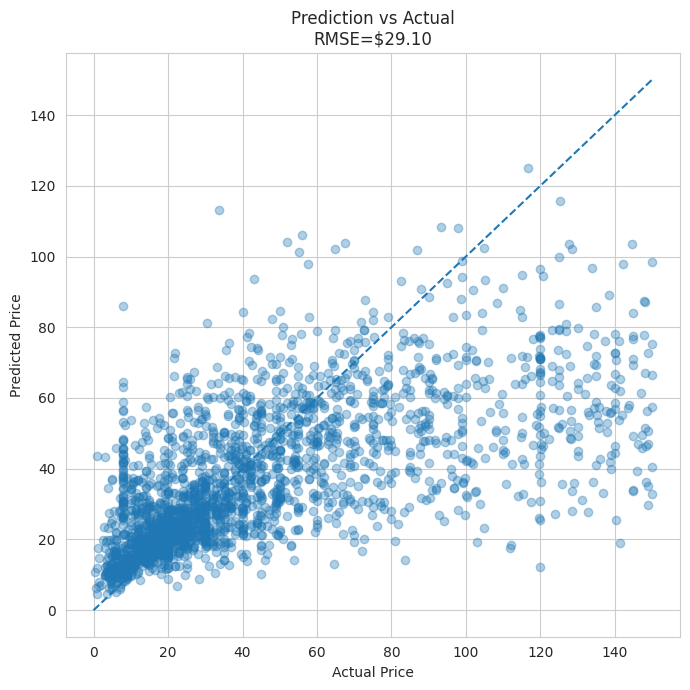


📌 ERROR ANALYSIS

TOP 10 BIGGEST ERRORS
       actual  predicted   abs_error
9297   141.46  18.894428  122.565572
11042  149.00  29.617193  119.382807
4881   150.00  32.983036  117.016964
4083   140.25  25.451420  114.798580
3441   149.00  35.145847  113.854153
2495   148.47  36.219673  112.250327
7853   145.00  33.834320  111.165680
9309   145.00  34.003685  110.996315
3344   150.00  40.400681  109.599319
1935   120.00  12.330755  107.669245

✅ Model saved!
✅ Feature importance saved!

📈 PHASE 8 REASONING


1. RandomizedSearchCV gagal karena:
   sklearn terbaru tidak kompatibel
   dengan beberapa build xgboost

2. Manual tuning lebih aman
   dan lebih mudah dianalisis

3. Learning rate kecil:
   → training lebih stabil
   → generalisasi lebih baik

4. n_estimators besar:
   → model belajar lebih detail

5. max_depth terlalu tinggi:
   → overfitting risk meningkat

6. Hybrid vector berhasil:
   - BERT semantic understanding
   - tabular business intelligence

7. category_te sangat pen

In [69]:
# ══════════════════════════════════════════════════════════════
# PHASE 8 │ ADVANCED XGBOOST MODELLING + HYPERPARAMETER TUNING
# Compatible dengan environment Kaggle terbaru (2026)
# FIX:
# ✅ sklearn-xgboost compatibility issue
# ✅ manual tuning (lebih stabil)
# ✅ early stopping
# ✅ feature importance
# ✅ evaluation lengkap
# ══════════════════════════════════════════════════════════════

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("=" * 60)
print("PHASE 8 │ ADVANCED XGBOOST MODELLING")
print("=" * 60)

# ============================================================
# 1. VALIDATION SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train_fit, X_valid, y_train_fit, y_valid = train_test_split(
    X_train_final,
    y_train,
    test_size=0.15,
    random_state=42
)

print("\n📦 DATA SPLIT")
print(f"Train Fit : {X_train_fit.shape}")
print(f"Valid     : {X_valid.shape}")

# ============================================================
# 2. MANUAL HYPERPARAMETER SEARCH
# ============================================================

print("\n⏳ Menjalankan Manual Hyperparameter Tuning...")

param_grid = [

    {
        "n_estimators": 600,
        "learning_rate": 0.03,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },

    {
        "n_estimators": 800,
        "learning_rate": 0.02,
        "max_depth": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.7
    },

    {
        "n_estimators": 1000,
        "learning_rate": 0.01,
        "max_depth": 6,
        "subsample": 0.9,
        "colsample_bytree": 0.7
    },

    {
        "n_estimators": 1200,
        "learning_rate": 0.01,
        "max_depth": 7,
        "subsample": 0.8,
        "colsample_bytree": 0.6
    },

    {
        "n_estimators": 1500,
        "learning_rate": 0.005,
        "max_depth": 8,
        "subsample": 0.7,
        "colsample_bytree": 0.6
    }
]

best_rmse = 999999
best_model = None
best_params = None

results = []

# ============================================================
# 3. TRAINING LOOP
# ============================================================

for i, params in enumerate(param_grid):

    print("\n" + "-" * 60)
    print(f"MODEL #{i+1}")
    print(params)

    t0 = time.time()

    model = XGBRegressor(

        # core
        objective="reg:squarederror",
        eval_metric="rmse",

        # tuning
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        max_depth=params["max_depth"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],

        # regularization
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.5,

        # speed
        tree_method="hist",

        # reproducibility
        random_state=42,

        # efficiency
        n_jobs=-1
    )

    # ========================================================
    # TRAIN
    # ========================================================

    model.fit(
        X_train_fit,
        y_train_fit,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    # ========================================================
    # VALIDATION PREDICTION
    # ========================================================

    pred_log = model.predict(X_valid)

    pred_price = np.expm1(pred_log)
    actual_price = np.expm1(y_valid)

    rmse = np.sqrt(
        mean_squared_error(actual_price, pred_price)
    )

    mae = mean_absolute_error(
        actual_price,
        pred_price
    )

    r2 = r2_score(
        actual_price,
        pred_price
    )

    elapsed = (time.time() - t0) / 60

    print(f"RMSE : ${rmse:.4f}")
    print(f"MAE  : ${mae:.4f}")
    print(f"R²   : {r2:.4f}")
    print(f"Time : {elapsed:.2f} menit")

    results.append({
        "params": params,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    })

    # ========================================================
    # BEST MODEL UPDATE
    # ========================================================

    if rmse < best_rmse:

        best_rmse = rmse
        best_model = model
        best_params = params

        print("✅ BEST MODEL UPDATED")

# ============================================================
# 4. FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("👑 BEST MODEL")
print("=" * 60)

print(f"\nBEST RMSE : ${best_rmse:.4f}")

print("\nBEST PARAMS")

for k, v in best_params.items():
    print(f"{k:20}: {v}")

# ============================================================
# 5. TEST EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("FINAL TEST EVALUATION")
print("=" * 60)

test_pred_log = best_model.predict(X_test_final)

test_pred_price = np.expm1(test_pred_log)
test_actual_price = np.expm1(y_test)

final_rmse = np.sqrt(
    mean_squared_error(
        test_actual_price,
        test_pred_price
    )
)

final_mae = mean_absolute_error(
    test_actual_price,
    test_pred_price
)

final_r2 = r2_score(
    test_actual_price,
    test_pred_price
)

print(f"\n🎯 FINAL RMSE : ${final_rmse:.4f}")
print(f"🎯 FINAL MAE  : ${final_mae:.4f}")
print(f"🎯 FINAL R²   : {final_r2:.4f}")

# ============================================================
# 6. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 60)
print("📌 FEATURE IMPORTANCE")
print("=" * 60)

# generate feature names
bert_feature_names = [
    f"bert_{i}" for i in range(384)
]

all_feature_names = (
    bert_feature_names +
    NUM_COLS
)

importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": best_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print("\n🔥 TOP 20 FEATURES")
print(
    importance_df.head(20).to_string(index=False)
)

# ============================================================
# 7. FEATURE IMPORTANCE PLOT
# ============================================================

top20 = importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top20["feature"][::-1],
    top20["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importance")

plt.tight_layout()
plt.show()

# ============================================================
# 8. PREDICTION VISUALIZATION
# ============================================================

plt.figure(figsize=(7,7))

plt.scatter(
    test_actual_price,
    test_pred_price,
    alpha=0.35
)

plt.plot(
    [0, 150],
    [0, 150],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title(
    f"Prediction vs Actual\nRMSE=${final_rmse:.2f}"
)

plt.tight_layout()
plt.show()

# ============================================================
# 9. ERROR ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("📌 ERROR ANALYSIS")
print("=" * 60)

error_df = pd.DataFrame({
    "actual": test_actual_price,
    "predicted": test_pred_price
})

error_df["abs_error"] = np.abs(
    error_df["actual"] - error_df["predicted"]
)

print("\nTOP 10 BIGGEST ERRORS")

print(
    error_df
    .sort_values("abs_error", ascending=False)
    .head(10)
)

# ============================================================
# 10. SAVE MODEL
# ============================================================

import joblib

joblib.dump(
    best_model,
    "wantilan_xgb_best_model.joblib"
)

importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

print("\n✅ Model saved!")
print("✅ Feature importance saved!")


print("\n🎉 PHASE 8 ADVANCED MODELLING SELESAI!")